In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Manga vs Anime part II

## Additional tricks and EDA

In [2]:
manga_data = pd.read_csv('Data/manga.csv')
anime_data = pd.read_csv('Data/anime.csv')

In [3]:
manga_data

,manga_id,title,type,score,scored_by,status,volumes,chapters,start_date,end_date,...,demographics,authors,serializations,synopsis,background,main_picture,url,title_english,title_japanese,title_synonyms
0,2,Berserk,manga,9.47,319696,currently_publishing,NaN,NaN,1989-08-25,NaN,...,['Seinen'],"[{'id': 1868, 'first_name': 'Kentarou', 'last_...",['Young Animal'],"Guts, a former mercenary now known as the ""Bla...",Berserk won the Award for Excellence at the si...,https://cdn.myanimelist.net/images/manga/1/157...,https://myanimelist.net/manga/2/Berserk,Berserk,ベルセルク,['Berserk: The Prototype']
1,13,One Piece,manga,9.22,355375,currently_publishing,NaN,NaN,1997-07-22,NaN,...,['Shounen'],"[{'id': 1881, 'first_name': 'Eiichiro', 'last_...",['Shounen Jump (Weekly)'],"Gol D. Roger, a man referred to as the ""King o...",One Piece is the highest selling manga series ...,https://cdn.myanimelist.net/images/manga/2/253...,https://myanimelist.net/manga/13/One_Piece,One Piece,ONE PIECE,[]
2,1706,JoJo no Kimyou na Bouken Part 7: Steel Ball Run,manga,9.30,151433,finished,24.0,96.0,2004-01-19,2011-04-19,...,"['Seinen', 'Shounen']","[{'id': 2619, 'first_name': 'Hirohiko', 'last_...",['Ultra Jump'],"In the American Old West, the world's greatest...",JoJo no Kimyou na Bouken Part 7: Steel Ball Ru...,https://cdn.myanimelist.net/images/manga/3/179...,https://myanimelist.net/manga/1706/JoJo_no_Kim...,NaN,ジョジョの奇妙な冒険 Part7 STEEL BALL RUN,"[""JoJo's Bizarre Adventure Part 7: Steel Ball ..."
3,4632,Oyasumi Punpun,manga,9.02,168459,finished,13.0,147.0,2007-03-15,2013-11-02,...,['Seinen'],"[{'id': 2836, 'first_name': 'Inio', 'last_name...",['Big Comic Spirits'],Punpun Onodera is a normal 11-year-old boy liv...,Oyasumi Punpun was originally serialized in Yo...,https://cdn.myanimelist.net/images/manga/3/266...,https://myanimelist.net/manga/4632/Oyasumi_Punpun,Goodnight Punpun,おやすみプンプン,[]
4,25,Fullmetal Alchemist,manga,9.03,153151,finished,27.0,116.0,2001-07-12,2010-09-11,...,['Shounen'],"[{'id': 1874, 'first_name': 'Hiromu', 'last_na...",['Shounen Gangan'],Alchemists are knowledgeable and naturally tal...,Hagane no Renkinjutsushi won the 49th Shogakuk...,https://cdn.myanimelist.net/images/manga/3/243...,https://myanimelist.net/manga/25/Fullmetal_Alc...,Fullmetal Alchemist,鋼の錬金術師,"['Full Metal Alchemist', 'Hagane no Renkinjuts..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64828,158691,Raise wa Kimi no Mono,manga,NaN,1,finished,1.0,8.0,2018-08-30,2019-04-10,...,['Shoujo'],"[{'id': 21499, 'first_name': 'Chizu', 'last_na...",['Comic Flavors'],Saya is living under strained family circumsta...,NaN,https://cdn.myanimelist.net/images/manga/2/285...,https://myanimelist.net/manga/158691/Raise_wa_...,NaN,来世は君のもの,[]
64829,159388,Ore to Basil no Automata,manga,NaN,0,finished,2.0,19.0,2013-01-19,2014-04-19,...,[],"[{'id': 51217, 'first_name': 'Ryou', 'last_nam...",['Magazine Special'],"Kamiya Mitsugu, a perverted high school studen...",NaN,https://cdn.myanimelist.net/images/manga/1/282...,https://myanimelist.net/manga/159388/Ore_to_Ba...,NaN,俺とバジルの魔法人形〈オートマタ〉,['Ore to Basil no Mahou Ningyou']
64830,160296,Happy Candy Virus,manga,NaN,0,finished,4.0,54.0,2021-08-02,2023-03-13,...,[],"[{'id': 67322, 'first_name': 'Kaori', 'last_na...",['Manga Park'],NaN,NaN,https://cdn.myanimelist.net/images/manga/3/286...,https://myanimelist.net/manga/160296/Happy_Can...,NaN,ハッピーキャンディーウイルス,[]
64831,160604,Suibu Yametai Hagino-san,one_shot,NaN,0,finished,NaN,1.0,2022-03-03,2022-03-03,...,['Shounen'],"[{'id': 67029, 'first_name': '', 'last_name': ...",['Shounen Champion (Weekly)'],NaN,NaN,https://cdn.myanimelist.net/images/manga/2/285...,https://myanimelist.net/manga/160604/Suibu_Yam...,NaN,吹部やめたい萩野さん,[]


In [4]:
manga_data.shape

(64833, 30)

In [5]:
anime_data

,anime_id,title,type,score,scored_by,status,episodes,start_date,end_date,source,...,producers,licensors,synopsis,background,main_picture,url,trailer_url,title_english,title_japanese,title_synonyms
0,5114,Fullmetal Alchemist: Brotherhood,tv,9.10,2037075,finished_airing,64.0,2009-04-05,2010-07-04,manga,...,"['Aniplex', 'Square Enix', 'Mainichi Broadcast...","['Funimation', 'Aniplex of America']",After a horrific alchemy experiment goes wrong...,NaN,https://cdn.myanimelist.net/images/anime/1208/...,https://myanimelist.net/anime/5114/Fullmetal_A...,https://www.youtube.com/watch?v=--IcmZkvL0Q,Fullmetal Alchemist: Brotherhood,鋼の錬金術師 FULLMETAL ALCHEMIST,['Hagane no Renkinjutsushi: Fullmetal Alchemis...
1,11061,Hunter x Hunter (2011),tv,9.04,1671587,finished_airing,148.0,2011-10-02,2014-09-24,manga,...,"['VAP', 'Nippon Television Network', 'Shueisha']",['VIZ Media'],Hunters devote themselves to accomplishing haz...,NaN,https://cdn.myanimelist.net/images/anime/1337/...,https://myanimelist.net/anime/11061/Hunter_x_H...,https://www.youtube.com/watch?v=D9iTQRB4XRk,Hunter x Hunter,HUNTER×HUNTER（ハンター×ハンター）,['HxH (2011)']
2,38524,Shingeki no Kyojin Season 3 Part 2,tv,9.05,1491491,finished_airing,10.0,2019-04-29,2019-07-01,manga,...,"['Production I.G', 'Dentsu', 'Mainichi Broadca...",['Funimation'],Seeking to restore humanity's diminishing hope...,Shingeki no Kyojin adapts content from volumes...,https://cdn.myanimelist.net/images/anime/1517/...,https://myanimelist.net/anime/38524/Shingeki_n...,https://www.youtube.com/watch?v=hKHepjfj5Tw,Attack on Titan Season 3 Part 2,進撃の巨人 Season3 Part.2,[]
3,9253,Steins;Gate,tv,9.07,1348232,finished_airing,24.0,2011-04-06,2011-09-14,visual_novel,...,"['Frontier Works', 'Media Factory', 'Kadokawa ...",['Funimation'],Eccentric scientist Rintarou Okabe has a never...,Steins;Gate is based on 5pb. and Nitroplus' vi...,https://cdn.myanimelist.net/images/anime/1935/...,https://myanimelist.net/anime/9253/Steins_Gate,https://www.youtube.com/watch?v=27OZc-ku6is,Steins;Gate,STEINS;GATE,[]
4,28851,Koe no Katachi,movie,8.94,1540277,finished_airing,1.0,2016-09-17,2016-09-17,manga,...,"['Shochiku', 'Pony Canyon', 'Kodansha', 'ABC A...","['Eleven Arts', 'NYAV Post']","As a wild youth, elementary school student Sho...",Koe no Katachi won the following awards: Japan...,https://cdn.myanimelist.net/images/anime/1122/...,https://myanimelist.net/anime/28851/Koe_no_Kat...,https://www.youtube.com/watch?v=XBNWo25izJ8,A Silent Voice,聲の形,['The Shape of Voice']
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24980,54574,Seizoki,movie,NaN,10,finished_airing,1.0,1964-01-01,1964-01-01,original,...,[],[],"This is an animation using the ""Kaki-mation"" t...",NaN,https://cdn.myanimelist.net/images/anime/1202/...,https://myanimelist.net/anime/54574/Seizoki,NaN,NaN,精造機,[]
24981,56159,Kanshajou,music,NaN,2,finished_airing,1.0,1993-02-02,1993-02-02,original,...,['NHK'],[],Music video for the song Kanshajou by Reiko Sa...,NaN,https://cdn.myanimelist.net/images/anime/1074/...,https://myanimelist.net/anime/56159/Kanshajou,NaN,NaN,感謝状,['Minna no Uta']
24982,56107,Kaijuu Sekai Seifuku,ona,NaN,2,currently_airing,NaN,2020-04-02,NaN,web_manga,...,[],[],Follows four dragon-like monsters who came to ...,NaN,https://cdn.myanimelist.net/images/anime/1859/...,https://myanimelist.net/anime/56107/Kaijuu_Sek...,NaN,NaN,かいじゅうせかいせいふく,[]
24983,56168,Yotsukado no Melody,music,NaN,1,finished_airing,1.0,2014-12-01,2014-12-01,original,...,['NHK'],[],Music video for the song Yotsukado no Melody b...,NaN,https://cdn.myanimelist.net/images/anime/1559/...,https://myanimelist.net/anime/56168/Yotsukado_...,NaN,NaN,四つ角のメロディー,['Minna no Uta']


In [6]:
anime_data.shape

(24985, 39)

In [7]:
set(manga_data.columns) - set(anime_data.columns)

{'authors',
 'chapters',
 'created_at_before',
 'manga_id',
 'serializations',
 'volumes'}

In [8]:
set(anime_data.columns) - set(manga_data.columns)

{'anime_id',
 'broadcast_day',
 'broadcast_time',
 'created_at',
 'episode_duration',
 'episodes',
 'licensors',
 'producers',
 'rating',
 'source',
 'start_season',
 'start_year',
 'studios',
 'total_duration',
 'trailer_url'}

In [9]:
set(manga_data.columns) & set(anime_data.columns)

{'approved',
 'background',
 'demographics',
 'end_date',
 'favorites',
 'genres',
 'main_picture',
 'members',
 'real_end_date',
 'real_start_date',
 'score',
 'scored_by',
 'sfw',
 'start_date',
 'status',
 'synopsis',
 'themes',
 'title',
 'title_english',
 'title_japanese',
 'title_synonyms',
 'type',
 'updated_at',
 'url'}

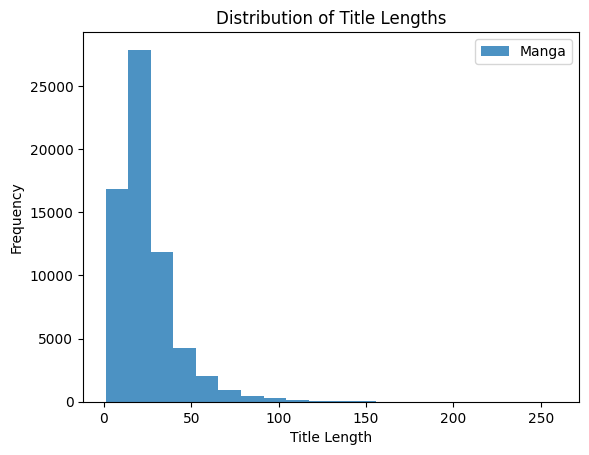

In [11]:
plt.hist(manga_data.title.str.len(), bins=20, alpha=0.8, label='Manga')
plt.xlabel('Title Length')
plt.ylabel('Frequency')
plt.title('Distribution of Title Lengths')
plt.legend()
plt.show()

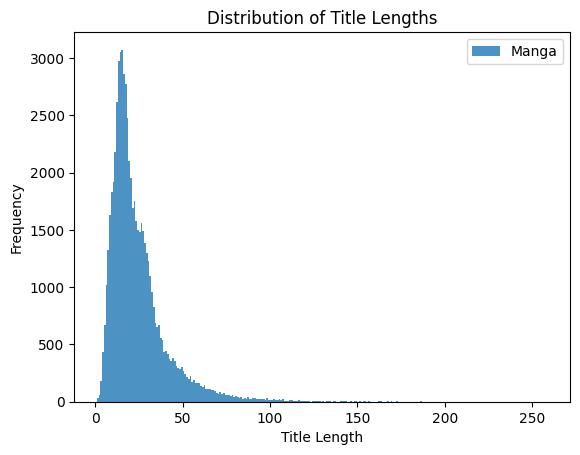

In [12]:
plt.hist(manga_data.title.str.len(), bins='fd', alpha=0.8, label='Manga')
plt.xlabel('Title Length')
plt.ylabel('Frequency')
plt.title('Distribution of Title Lengths')
plt.legend()
plt.show()

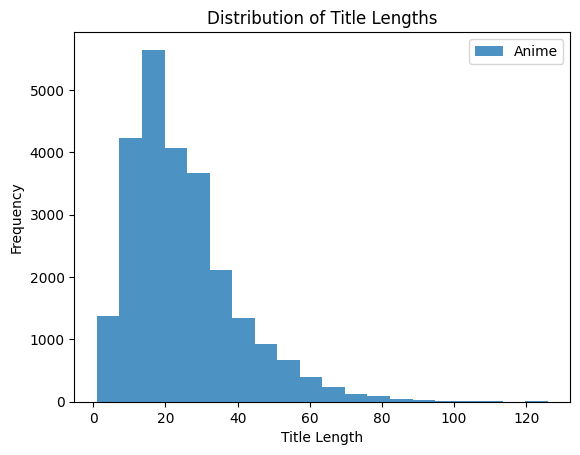

In [13]:
plt.hist(anime_data.title.str.len(), bins=20, alpha=0.8, label='Anime')
plt.xlabel('Title Length')
plt.ylabel('Frequency')
plt.title('Distribution of Title Lengths')
plt.legend()
plt.show()

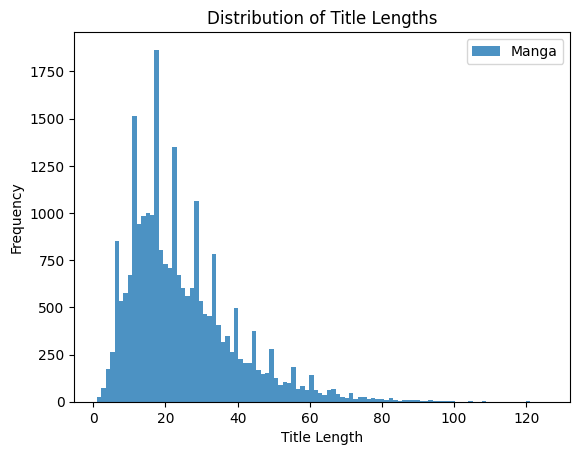

In [19]:
n, bins, patches = plt.hist(anime_data.title.str.len(), bins='fd', alpha=0.8, label='Manga')
plt.xlabel('Title Length')
plt.ylabel('Frequency')
plt.title('Distribution of Title Lengths')
plt.legend()
plt.show()

In [21]:
list(zip(bins[:-1], bins[1:]))

[(np.float64(1.0), np.float64(2.2254901960784315)),
 (np.float64(2.2254901960784315), np.float64(3.450980392156863)),
 (np.float64(3.450980392156863), np.float64(4.676470588235294)),
 (np.float64(4.676470588235294), np.float64(5.901960784313726)),
 (np.float64(5.901960784313726), np.float64(7.127450980392157)),
 (np.float64(7.127450980392157), np.float64(8.352941176470589)),
 (np.float64(8.352941176470589), np.float64(9.57843137254902)),
 (np.float64(9.57843137254902), np.float64(10.803921568627452)),
 (np.float64(10.803921568627452), np.float64(12.029411764705884)),
 (np.float64(12.029411764705884), np.float64(13.254901960784315)),
 (np.float64(13.254901960784315), np.float64(14.480392156862745)),
 (np.float64(14.480392156862745), np.float64(15.705882352941178)),
 (np.float64(15.705882352941178), np.float64(16.93137254901961)),
 (np.float64(16.93137254901961), np.float64(18.15686274509804)),
 (np.float64(18.15686274509804), np.float64(19.38235294117647)),
 (np.float64(19.3823529411764

In [22]:
title_lengths = anime_data.title.str.len()

In [23]:
title_lengths

0        32
1        22
2        34
3        11
4        14
         ..
24980     7
24981     9
24982    20
24983    19
24984    13
Name: title, Length: 24985, dtype: int64

In [24]:
current_title_lengths = title_lengths[(title_lengths >= 15) & (title_lengths <= 18)]

In [25]:
current_title_lengths

15       17
16       18
19       17
24       16
48       16
         ..
24940    16
24942    18
24954    17
24955    16
24966    17
Name: title, Length: 3853, dtype: int64

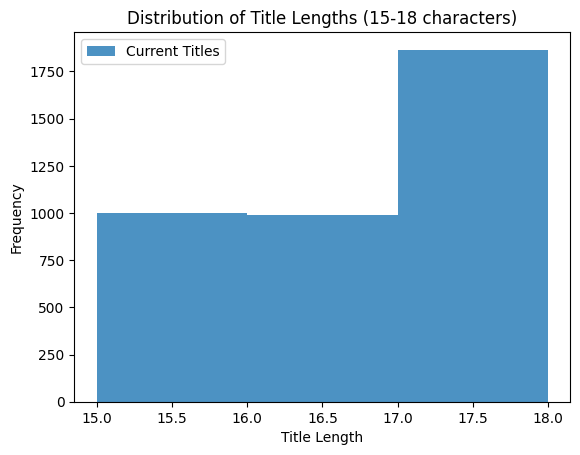

In [26]:
plt.hist(current_title_lengths, bins='fd', alpha=0.8, label='Current Titles')
plt.xlabel('Title Length')
plt.ylabel('Frequency') 
plt.title('Distribution of Title Lengths (15-18 characters)')
plt.legend()
plt.show()

(array([998.,   0.,   0., 990.,   0.,   0., 946.,   0.,   0., 919.]),
 array([15. , 15.3, 15.6, 15.9, 16.2, 16.5, 16.8, 17.1, 17.4, 17.7, 18. ]),
 <BarContainer object of 10 artists>)

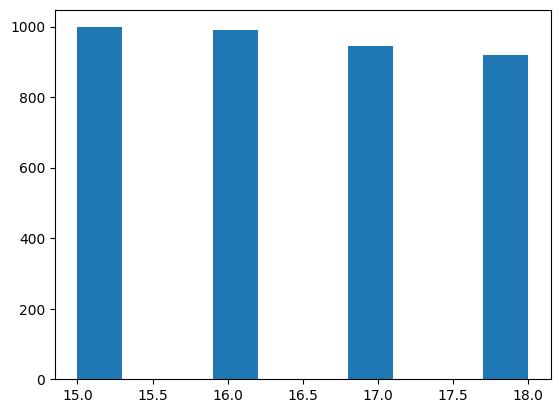

In [27]:
plt.hist(current_title_lengths)

In [28]:
current_title_lengths = title_lengths[title_lengths == 30]

In [29]:
current_title_lengths

129      30
155      30
161      30
220      30
363      30
         ..
24797    30
24799    30
24817    30
24891    30
24894    30
Name: title, Length: 532, dtype: int64

In [30]:
anime_data.loc[current_title_lengths.index]

,anime_id,title,type,score,scored_by,status,episodes,start_date,end_date,source,...,producers,licensors,synopsis,background,main_picture,url,trailer_url,title_english,title_japanese,title_synonyms
129,37430,Tensei shitara Slime Datta Ken,tv,8.14,825679,finished_airing,24.0,2018-10-02,2019-03-19,manga,...,"['Lantis', 'Kodansha', 'BS11', 'Bandai Namco A...",['Funimation'],Thirty-seven-year-old Satoru Mikami is a typic...,NaN,https://cdn.myanimelist.net/images/anime/1069/...,https://myanimelist.net/anime/37430/Tensei_shi...,https://www.youtube.com/watch?v=bkQkyzXEXKE,That Time I Got Reincarnated as a Slime,転生したらスライムだった件,['TenSura']
155,9260,Kizumonogatari I: Tekketsu-hen,movie,8.37,274194,finished_airing,1.0,2016-01-08,2016-01-08,light_novel,...,"['Aniplex', 'Kodansha']",['Aniplex of America'],During Koyomi Araragi's second year at Naoetsu...,The Kizumonogatari movie trilogy adapts the th...,https://cdn.myanimelist.net/images/anime/1783/...,https://myanimelist.net/anime/9260/Kizumonogat...,https://www.youtube.com/watch?v=4lt0rT_nmvg,Kizumonogatari Part 1: Iron-Blooded,傷物語〈Ⅰ鉄血篇〉,['Koyomi Vamp']
161,32282,Shokugeki no Souma: Ni no Sara,tv,8.09,704371,finished_airing,13.0,2016-07-02,2016-09-24,manga,...,"['Dentsu', 'Lantis', 'Mainichi Broadcasting Sy...",['Sentai Filmworks'],The qualifiers of the Autumn Elections are now...,NaN,https://cdn.myanimelist.net/images/anime/8/793...,https://myanimelist.net/anime/32282/Shokugeki_...,https://www.youtube.com/watch?v=ftkShI-StTU,Food Wars! The Second Plate,食戟のソーマ 弍ノ皿,"['Shokugeki no Souma 2nd Season', 'Shokugeki n..."
220,5258,Hajime no Ippo: New Challenger,tv,8.66,158388,finished_airing,26.0,2009-01-07,2009-07-01,manga,...,"['VAP', 'Kodansha', 'Nippon Television Network']",[],Japanese Featherweight Champion Ippo Makunouch...,NaN,https://cdn.myanimelist.net/images/anime/8/566...,https://myanimelist.net/anime/5258/Hajime_no_I...,NaN,Fighting Spirit: New Challenger,はじめの一歩 新シリーズ,"['Hajime no Ippo New Series', 'Hajime no Ippo ..."
363,40956,Enen no Shouboutai: Ni no Shou,tv,7.81,381090,finished_airing,24.0,2020-07-04,2020-12-12,manga,...,"['Mainichi Broadcasting System', 'Kodansha', '...",['Funimation'],After his confrontation in the Nether with his...,NaN,https://cdn.myanimelist.net/images/anime/1673/...,https://myanimelist.net/anime/40956/Enen_no_Sh...,https://www.youtube.com/watch?v=NpDvoopi0AE,Fire Force Season 2,炎炎ノ消防隊 弐ノ章,"['Enen no Shouboutai 2nd Season', 'Fire Force ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24797,47190,Wei Wei Hou: Qingchun Fangxian,tv,NaN,7,finished_airing,26.0,2015-12-15,NaN,original,...,[],[],NaN,NaN,https://cdn.myanimelist.net/images/anime/1945/...,https://myanimelist.net/anime/47190/Wei_Wei_Ho...,NaN,NaN,威威猴之青春防线,[]
24799,47293,Piaoyi Dao: Tiankong Lixian Ji,tv,NaN,6,finished_airing,52.0,2016-02-22,NaN,NaN,...,[],[],NaN,NaN,https://cdn.myanimelist.net/images/anime/1961/...,https://myanimelist.net/anime/47293/Piaoyi_Dao...,NaN,NaN,漂移岛之天空历险记,[]
24817,55193,Midnight: Eraser Wars Spin-off,movie,NaN,9,finished_airing,1.0,2017-01-01,2017-01-01,original,...,[],[],NaN,NaN,https://cdn.myanimelist.net/images/anime/1750/...,https://myanimelist.net/anime/55193/Midnight__...,NaN,NaN,MIDNIGHT ~ Eraser WARS spin off,[]
24891,44917,Xinnian Lai La: Shenmi Baozang,tv,NaN,7,finished_airing,26.0,2015-01-01,2015-01-01,original,...,[],[],NaN,NaN,https://cdn.myanimelist.net/images/anime/1201/...,https://myanimelist.net/anime/44917/Xinnian_La...,NaN,NaN,新年来啦之神秘宝藏,[]


In [31]:
anime_data.loc[current_title_lengths.index].title.sort_values().to_csv('len_30.csv', index=False)

In [32]:
anime_data[anime_data.title.str.contains(":", regex=False)]

,anime_id,title,type,score,scored_by,status,episodes,start_date,end_date,source,...,producers,licensors,synopsis,background,main_picture,url,trailer_url,title_english,title_japanese,title_synonyms
0,5114,Fullmetal Alchemist: Brotherhood,tv,9.10,2037075,finished_airing,64.0,2009-04-05,2010-07-04,manga,...,"['Aniplex', 'Square Enix', 'Mainichi Broadcast...","['Funimation', 'Aniplex of America']",After a horrific alchemy experiment goes wrong...,NaN,https://cdn.myanimelist.net/images/anime/1208/...,https://myanimelist.net/anime/5114/Fullmetal_A...,https://www.youtube.com/watch?v=--IcmZkvL0Q,Fullmetal Alchemist: Brotherhood,鋼の錬金術師 FULLMETAL ALCHEMIST,['Hagane no Renkinjutsushi: Fullmetal Alchemis...
6,2904,Code Geass: Hangyaku no Lelouch R2,tv,8.91,1154270,finished_airing,25.0,2008-04-06,2008-09-28,original,...,"['Bandai Visual', 'Mainichi Broadcasting Syste...","['Funimation', 'Bandai Entertainment']","One year has passed since the Black Rebellion,...",Code Geass: Hangyaku no Lelouch R2 is an origi...,https://cdn.myanimelist.net/images/anime/1088/...,https://myanimelist.net/anime/2904/Code_Geass_...,NaN,Code Geass: Lelouch of the Rebellion R2,コードギアス 反逆のルルーシュ 続編,"['Code Geass: Hangyaku no Lelouch 2nd Season',..."
7,40028,Shingeki no Kyojin: The Final Season,tv,8.80,1237778,finished_airing,16.0,2020-12-07,2021-03-29,manga,...,"['Production I.G', 'Dentsu', 'Mainichi Broadca...",['Funimation'],Gabi Braun and Falco Grice have been training ...,Shingeki no Kyojin: The Final Season adapts co...,https://cdn.myanimelist.net/images/anime/1000/...,https://myanimelist.net/anime/40028/Shingeki_n...,https://www.youtube.com/watch?v=SlNpRThS9t8,Attack on Titan: Final Season,進撃の巨人 The Final Season,"['Shingeki no Kyojin Season 4', 'Attack on Tit..."
9,1575,Code Geass: Hangyaku no Lelouch,tv,8.70,1353753,finished_airing,25.0,2006-10-06,2007-07-29,original,...,"['Bandai Visual', 'Mainichi Broadcasting Syste...","['Funimation', 'Bandai Entertainment']","In the year 2010, the Holy Empire of Britannia...",Code Geass: Hangyaku no Lelouch is an original...,https://cdn.myanimelist.net/images/anime/1032/...,https://myanimelist.net/anime/1575/Code_Geass_...,NaN,Code Geass: Lelouch of the Rebellion,コードギアス 反逆のルルーシュ,[]
18,47778,Kimetsu no Yaiba: Yuukaku-hen,tv,8.79,805702,finished_airing,11.0,2021-12-05,2022-02-13,manga,...,"['Aniplex', 'Shueisha']","['Aniplex of America', 'Crunchyroll']",The devastation of the Mugen Train incident st...,Kimetsu no Yaiba: Yuukaku-hen adapts chapters ...,https://cdn.myanimelist.net/images/anime/1908/...,https://myanimelist.net/anime/47778/Kimetsu_no...,https://www.youtube.com/watch?v=QwvWdnd2Ktg,Demon Slayer: Kimetsu no Yaiba Entertainment D...,鬼滅の刃 遊郭編,[]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24923,55602,Ohiru no Shocker-san: The Movie,movie,NaN,7,finished_airing,1.0,2022-07-22,2022-07-22,other,...,[],[],NaN,The short was released on Toei Tokusatsu Fan C...,https://cdn.myanimelist.net/images/anime/1125/...,https://myanimelist.net/anime/55602/Ohiru_no_S...,NaN,Shocker During the Day: The Movie,お昼のショッカーさん THEムービィー,[]
24947,56109,Kagayaite Ite: 10 Years After,music,NaN,14,finished_airing,1.0,1995-06-01,1995-06-01,original,...,['NHK'],[],Music video for the song Kagayaite Ite: 10 Yea...,NaN,https://cdn.myanimelist.net/images/anime/1959/...,https://myanimelist.net/anime/56109/Kagayaite_...,NaN,NaN,輝いていて～10 years after～,['Minna no Uta']
24961,55971,Keio Yugekitai: Katsugeki-hen,ova,NaN,8,finished_airing,1.0,1996-01-01,1996-01-01,game,...,[],[],Rami Nana-Hikari's adventures continue as the ...,Promotional video based off the game of the sa...,https://cdn.myanimelist.net/images/anime/1246/...,https://myanimelist.net/anime/55971/Keio_Yugek...,NaN,Keio Flying Squadron,慶応遊撃隊活劇編,[]
24964,55846,Synapusyu The Movie: Push Hoppe New World,movie,NaN,5,finished_airing,1.0,2023-05-19,2023-05-19,NaN,...,"['TV Tokyo', 'CEKAI']",[],NaN,NaN,https://cdn.myanimelist.net/images/anime/1666/...,https://my

In [33]:
6543/len(anime_data)

0.2618771262757655

In [34]:
anime_data[anime_data.title.str.contains(":", regex=False)].sort_values('title')[['title', 'episodes', 'type']].to_csv('titles_with_colon.csv', index=False)

In [35]:
anime_data[anime_data.title.str.contains("season", case=False, regex=False)]

,anime_id,title,type,score,scored_by,status,episodes,start_date,end_date,source,...,producers,licensors,synopsis,background,main_picture,url,trailer_url,title_english,title_japanese,title_synonyms
2,38524,Shingeki no Kyojin Season 3 Part 2,tv,9.05,1491491,finished_airing,10.0,2019-04-29,2019-07-01,manga,...,"['Production I.G', 'Dentsu', 'Mainichi Broadca...",['Funimation'],Seeking to restore humanity's diminishing hope...,Shingeki no Kyojin adapts content from volumes...,https://cdn.myanimelist.net/images/anime/1517/...,https://myanimelist.net/anime/38524/Shingeki_n...,https://www.youtube.com/watch?v=hKHepjfj5Tw,Attack on Titan Season 3 Part 2,進撃の巨人 Season3 Part.2,[]
7,40028,Shingeki no Kyojin: The Final Season,tv,8.80,1237778,finished_airing,16.0,2020-12-07,2021-03-29,manga,...,"['Production I.G', 'Dentsu', 'Mainichi Broadca...",['Funimation'],Gabi Braun and Falco Grice have been training ...,Shingeki no Kyojin: The Final Season adapts co...,https://cdn.myanimelist.net/images/anime/1000/...,https://myanimelist.net/anime/40028/Shingeki_n...,https://www.youtube.com/watch?v=SlNpRThS9t8,Attack on Titan: Final Season,進撃の巨人 The Final Season,"['Shingeki no Kyojin Season 4', 'Attack on Tit..."
13,35760,Shingeki no Kyojin Season 3,tv,8.62,1524632,finished_airing,12.0,2018-07-23,2018-10-15,manga,...,"['Production I.G', 'Dentsu', 'Mainichi Broadca...",['Funimation'],"Still threatened by the ""Titans"" that rob them...",Shingeki no Kyojin Season 3 adapts content fro...,https://cdn.myanimelist.net/images/anime/1173/...,https://myanimelist.net/anime/35760/Shingeki_n...,https://www.youtube.com/watch?v=EHzBhrncmac,Attack on Titan Season 3,進撃の巨人 Season3,[]
22,25777,Shingeki no Kyojin Season 2,tv,8.51,1780194,finished_airing,12.0,2017-04-01,2017-06-17,manga,...,"['Production I.G', 'Dentsu', 'Mainichi Broadca...",['Funimation'],"For centuries, humanity has been hunted by gia...",Shingeki no Kyojin Season 2 adapts content fro...,https://cdn.myanimelist.net/images/anime/4/841...,https://myanimelist.net/anime/25777/Shingeki_n...,https://www.youtube.com/watch?v=zLaVP8IhIuc,Attack on Titan Season 2,進撃の巨人 Season2,[]
28,28891,Haikyuu!! Second Season,tv,8.63,907392,finished_airing,25.0,2015-10-04,2016-03-27,manga,...,"['Dentsu', 'Mainichi Broadcasting System', 'Mo...",['Sentai Filmworks'],Following their participation at the Inter-Hig...,Haikyuu!! Second Season is the sequel to the f...,https://cdn.myanimelist.net/images/anime/9/766...,https://myanimelist.net/anime/28891/Haikyuu_Se...,https://www.youtube.com/watch?v=SIg52zW5ncM,Haikyu!! 2nd Season,ハイキュー!! セカンドシーズン,['Haikyuu!! Second Season']
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24888,44523,Wo Jiao MT 5th Season,ona,NaN,9,finished_airing,10.0,2012-01-01,NaN,game,...,[],[],NaN,NaN,https://cdn.myanimelist.net/images/anime/1277/...,https://myanimelist.net/anime/44523/Wo_Jiao_MT...,NaN,NaN,我叫MT第五季,[]
24889,44525,Wo Jiao MT 6th Season,ona,NaN,9,finished_airing,21.0,2013-01-01,NaN,game,...,[],[],NaN,NaN,https://cdn.myanimelist.net/images/anime/1595/...,https://myanimelist.net/anime/44525/Wo_Jiao_MT...,NaN,NaN,我叫MT第六季,[]
24904,55068,Canzhuo Shang de Shi Shuo Xin Yu 2nd Season,ona,NaN,8,finished_airing,12.0,2019-10-25,2020-01-03,original,...,[],[],The second season of Canzhuo Shang De Shi Shuo...,NaN,https://cdn.myanimelist.net/images/anime/1697/...,https://myanimelist.net/anime/55068/Canzhuo_Sh...,NaN,NaN,餐桌上的世说新语 第二季,[]
24921,55119,Gon de Hanta 3rd Season,ona,NaN,9,finished_airing,20.0,2019-02-25,2019-07-15,original,...,[],[],The third season of Gon de Hanta.,NaN,https://cdn.myanimelist.net/images/anime/1338/...,https://myanimelist.net/anime/55119/Gon_de_Han...,NaN,NaN,Gon的旱獭 第三季,[]


In [37]:
anime_data[anime_data.title.str.contains("season", case=False, regex=False)].sort_values('title')[['title', 'episodes', 'type']] 

,title,episodes,type
16063,"""Oshi no Ko"" Season 2",NaN,tv
2939,100-man no Inochi no Ue ni Ore wa Tatteiru 2nd...,12.0,tv
8203,12-sai. 2nd Season,4.0,ova
5362,12-sai.: Chicchana Mune no Tokimeki 2nd Season,12.0,tv
159,3-gatsu no Lion 2nd Season,22.0,tv
...,...,...,...
19752,Zhandouban Geji! 2nd Season,14.0,ona
19483,Zhandouban Geji! Season Zero,4.0,ona
16663,Zhen Hun Jie 3rd Season,16.0,ona
16773,Zhen Wu Dianfeng 2nd Season,52.0,ona


In [40]:
anime_data[anime_data.title.str.contains("season", case=False, regex=False)].title.str.split(":", expand=True)[0]

2                 Shingeki no Kyojin Season 3 Part 2
7                                 Shingeki no Kyojin
13                       Shingeki no Kyojin Season 3
22                       Shingeki no Kyojin Season 2
28                           Haikyuu!! Second Season
                            ...                     
24888                          Wo Jiao MT 5th Season
24889                          Wo Jiao MT 6th Season
24904    Canzhuo Shang de Shi Shuo Xin Yu 2nd Season
24921                        Gon de Hanta 3rd Season
24962               Buffett Shenmi Julebu 2nd Season
Name: 0, Length: 770, dtype: str

In [41]:
anime_data[anime_data.title.str.contains("season", case=False, regex=False)].title.str.split(":", expand=True)[0].value_counts()    

0
Cardfight!! Vanguard                           7
Pokemon Best Wishes! Season 2                  5
Cinderella Girls Gekijou                       5
AU                                             5
Shingeki no Kyojin                             4
                                              ..
Wo Jiao MT 5th Season                          1
Wo Jiao MT 6th Season                          1
Canzhuo Shang de Shi Shuo Xin Yu 2nd Season    1
Gon de Hanta 3rd Season                        1
Buffett Shenmi Julebu 2nd Season               1
Name: count, Length: 714, dtype: int64

In [42]:
title_lengts = manga_data.title.str.len()

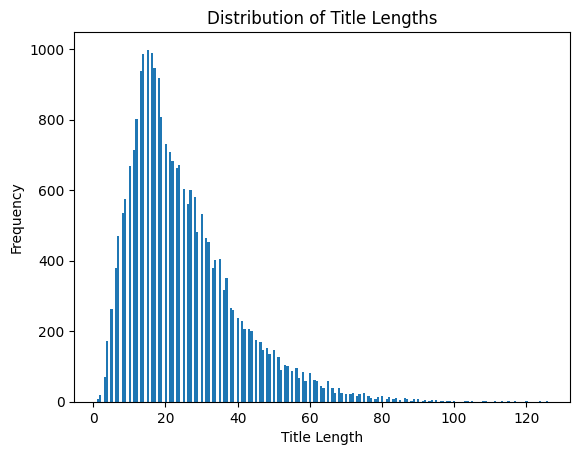

In [44]:
plt.hist(title_lengths, bins=200)
plt.xlabel('Title Length')
plt.ylabel('Frequency')
plt.title('Distribution of Title Lengths')
plt.show()

In [48]:
title_lengts[title_lengts >= 200]

25590    202
45778    233
56691    259
63963    210
64640    214
Name: title, dtype: int64

In [50]:
long_titles = title_lengts[title_lengts >= 150]

In [51]:
long_title_items = manga_data.loc[long_titles.index]

In [52]:
long_title_items

,manga_id,title,type,score,scored_by,status,volumes,chapters,start_date,end_date,...,demographics,authors,serializations,synopsis,background,main_picture,url,title_english,title_japanese,title_synonyms
5516,130629,"Konyaku Haki sareta Reijou wo Hirotta Ore ga, ...",manga,7.20,923,currently_publishing,NaN,NaN,2020-03-26,NaN,...,[],"[{'id': 49926, 'first_name': 'Ichiho', 'last_n...",['Comic PASH!'],"Deep in the forest lives Allen, a misanthropic...",NaN,https://cdn.myanimelist.net/images/manga/2/236...,https://myanimelist.net/manga/130629/Konyaku_H...,I'm Giving the Disgraced Noble Lady I Rescued ...,婚約破棄された令嬢を拾った俺が、イケナイことを教え込む ～美味しいものを食べさせておしゃれを...,[]
6176,136930,Shinjiteita Nakama-tachi ni Dungeon Okuchi de ...,manga,6.94,2019,currently_publishing,NaN,NaN,2021-05-25,NaN,...,[],"[{'id': 34603, 'first_name': 'Shisui', 'last_n...",['Magazine pocket'],A kid named Light is the only human member of ...,Shinjiteita Nakama-tachi ni Dungeon Okuchi de ...,https://cdn.myanimelist.net/images/manga/3/248...,https://myanimelist.net/manga/136930/Shinjitei...,Backstabbed in a Backwater Dungeon: My Party T...,信じていた仲間達にダンジョン奥地で殺されかけたがギフト『無限ガチャ』でレベル9999の仲間達...,['My Gift Lv9999 Unlimited Gacha']
8164,131563,Kage no Eiyuu no Nichijou-tan: Yuusha no Ura d...,manga,6.84,1340,currently_publishing,NaN,NaN,2020-07-27,NaN,...,[],"[{'id': 51096, 'first_name': 'Yuusaku', 'last_...",['Comp Ace'],"The ""Great War of Heroes,"" in which the hero a...",NaN,https://cdn.myanimelist.net/images/manga/3/239...,https://myanimelist.net/manga/131563/Kage_no_E...,NaN,影の英雄の日常譚 勇者の裏で暗躍していた最強のエージェント。組織が解体されたので、正体隠して...,"[""Shadow Hero's Daily Life"", ""Shadow Hero's Ev..."
10613,144291,Ryuu to Ayumu Nariagari Boukensha-dou: Youzumi...,manga,6.81,695,currently_publishing,NaN,NaN,2021-09-06,NaN,...,[],"[{'id': 42014, 'first_name': 'Kazuha', 'last_n...",['Manga Yomonga'],NaN,NaN,https://cdn.myanimelist.net/images/manga/1/256...,https://myanimelist.net/manga/144291/Ryuu_to_A...,NaN,竜と歩む成り上がり冒険者道～用済みとしてSランクパーティから追放された回復魔術師、捨てられた...,"['Take the Same Path as Dragon', 'A Story Abou..."
14483,153408,Osananajimi Kanojo no Morahara ga Hidoi nde Ze...,manga,6.38,928,currently_publishing,NaN,NaN,2022-11-01,NaN,...,[],"[{'id': 27741, 'first_name': '', 'last_name': ...",['Suiyoubi wa Mattari Dash X Comic'],My childhood friend is also my girlfriend. A d...,NaN,https://cdn.myanimelist.net/images/manga/1/282...,https://myanimelist.net/manga/153408/Osananaji...,NaN,幼馴染彼女のモラハラがひどいんで絶縁宣言してやった ~自分らしく生きることにしたら、なぜか隣...,"[""I'm Sick and Tired of My Childhood Friend's,..."
15566,141387,Shokubutsu Monster Musume Nikki: Seijo Datta W...,manga,7.06,154,currently_publishing,NaN,NaN,2021-10-23,NaN,...,[],"[{'id': 55534, 'first_name': '', 'last_name': ...",['ComicWalker'],NaN,NaN,https://cdn.myanimelist.net/images/manga/2/258...,https://myanimelist.net/manga/141387/Shokubuts...,Plant Monster Girl Diary,植物モンスター娘日記 ～聖女だった私が裏切られた果てにアルラウネに転生してしまったので、これ...,[]
18234,152596,Souzou Renkinjutsushi wa Jiyuu wo Ouka suru: K...,manga,6.82,176,currently_publishing,NaN,NaN,2021-06-22,NaN,...,[],"[{'id': 30477, 'first_name': 'Taka', 'last_nam...",['Young Ace UP'],The story centers around a bureaucrat named Th...,NaN,https://cdn.myanimelist.net/images/manga/1/270...,https://myanimelist.net/manga/152596/Souzou_Re...,NaN,創造錬金術師は自由を謳歌する 故郷を追放されたら、魔王のお膝元で超絶効果のマジックアイテム作...,[]
18451,151676,"""Sekai Saikyou no Shitsuji"" Black Shokuba wo T...",manga,6.57,296,currently_publishing,NaN,NaN,2022-06-14,NaN,...,['Seinen'],"[{'id': 61155, 'first_name': '', 'last_name': ...",['Isekai Yanjan'],NaN,NaN,https://cdn.myanimelist.net/images/manga/5/271...,https://myanimelist.net/manga/151676/Sekai_Sai...,NaN,【世界最強の執事】ブラック職場を追放された俺、氷の令嬢に拾われる ～生活魔法を駆使して無双し...,"[""The World's Strongest Butler""]"
18803,144848,"""Mou.... Hatarakitakunai n desu"": Boukensha na...",manga,6.59,269,currently_publishing,NaN,NaN,2021-06-30,NaN,...,[],"[{'id': 52385, 'first_name': 'Meishi', 'last_n...",['Gangan Online'],Aix is a 19-year-old E-rank adventurer. He is .

In [54]:
long_title_items.title

5516     Konyaku Haki sareta Reijou wo Hirotta Ore ga, ...
6176     Shinjiteita Nakama-tachi ni Dungeon Okuchi de ...
8164     Kage no Eiyuu no Nichijou-tan: Yuusha no Ura d...
10613    Ryuu to Ayumu Nariagari Boukensha-dou: Youzumi...
14483    Osananajimi Kanojo no Morahara ga Hidoi nde Ze...
15566    Shokubutsu Monster Musume Nikki: Seijo Datta W...
18234    Souzou Renkinjutsushi wa Jiyuu wo Ouka suru: K...
18451    "Sekai Saikyou no Shitsuji" Black Shokuba wo T...
18803    "Mou.... Hatarakitakunai n desu": Boukensha na...
19329    Hazure Skill "Gacha" de Tsuihou sareta Ore wa,...
20314    Akuyaku Reijou to Akuyaku Reisoku ga, Deatte K...
20826    Watashi yori Tsuyoi Otoko to Kekkon shitai no:...
23206    Sono Munou, Jitsu wa Sekai Saikyou no Mahoutsu...
23742    Kamigami no Kago de Seisan Kakumei: Isekai no ...
23999    Ningen dakedo Maougun Shitennou ni Sodateraret...
24541    Yarichin no Ore ga Boukan ni Osowareteta Otona...
24657    (Kono Sekai wa Mou Ore ga Sukutte Tomi to Kenr.

In [55]:
long_title_items.title.to_csv('long_titles.csv', index=False)

In [56]:
pd.qcut(title_lengts, 10)

0         (0.999, 9.0]
1         (0.999, 9.0]
2        (44.0, 259.0]
3         (12.0, 14.0]
4         (17.0, 19.0]
             ...      
64828     (19.0, 23.0]
64829     (23.0, 27.0]
64830     (14.0, 17.0]
64831     (23.0, 27.0]
64832     (27.0, 32.0]
Name: title, Length: 64833, dtype: category
Categories (10, interval[float64, right]): [(0.999, 9.0] < (9.0, 12.0] < (12.0, 14.0] < (14.0, 17.0] ... (23.0, 27.0] < (27.0, 32.0] < (32.0, 44.0] < (44.0, 259.0]]

In [57]:
pd.qcut(title_lengts, 10).value_counts()

title
(14.0, 17.0]     8712
(0.999, 9.0]     7181
(19.0, 23.0]     6973
(9.0, 12.0]      6713
(32.0, 44.0]     6333
(44.0, 259.0]    6295
(12.0, 14.0]     6036
(23.0, 27.0]     6026
(27.0, 32.0]     5978
(17.0, 19.0]     4586
Name: count, dtype: int64

In [58]:
pd.qcut(title_lengts, 10).value_counts().sort_index()

title
(0.999, 9.0]     7181
(9.0, 12.0]      6713
(12.0, 14.0]     6036
(14.0, 17.0]     8712
(17.0, 19.0]     4586
(19.0, 23.0]     6973
(23.0, 27.0]     6026
(27.0, 32.0]     5978
(32.0, 44.0]     6333
(44.0, 259.0]    6295
Name: count, dtype: int64

In [60]:
title_lengts[title_lengts > 42]

2         47
7         58
19        59
39        53
53        47
        ... 
64803     45
64806    116
64809     95
64815     44
64827     62
Name: title, Length: 7029, dtype: int64

In [62]:
manga_data.loc[title_lengts[title_lengts > 53].index]  

,manga_id,title,type,score,scored_by,status,volumes,chapters,start_date,end_date,...,demographics,authors,serializations,synopsis,background,main_picture,url,title_english,title_japanese,title_synonyms
7,90125,Kaguya-sama wa Kokurasetai: Tensai-tachi no Re...,manga,8.92,123341,finished,28.0,281.0,2015-05-19,2022-11-02,...,['Seinen'],"[{'id': 2139, 'first_name': 'Aka', 'last_name'...",['Young Jump'],Considered a genius due to having the highest ...,Kaguya-sama wa Kokurasetai: Tensai-tachi no Re...,https://cdn.myanimelist.net/images/manga/3/188...,https://myanimelist.net/manga/90125/Kaguya-sam...,Kaguya-sama: Love Is War,かぐや様は告らせたい～天才たちの恋愛頭脳戦～,"[""Kaguya Wants to be Confessed To: The Geniuse..."
19,100448,"Jumyou wo Kaitotte Moratta. Ichinen ni Tsuki, ...",manga,8.79,82303,finished,3.0,18.0,2016-08-10,2017-10-25,...,['Shounen'],"[{'id': 17059, 'first_name': 'Shouichi', 'last...",['Shounen Jump+'],"Helpless and struggling for cash, 20-year-old ...",The series is based on the novel Mikkakan no K...,https://cdn.myanimelist.net/images/manga/5/260...,https://myanimelist.net/manga/100448/Jumyou_wo...,I sold my life for ten thousand yen per year.,寿命を買い取ってもらった。一年につき、一万円で。,"['Mikkakan no Koufuku', 'Three Days of Happine..."
141,123992,Youkoso Jitsuryoku Shijou Shugi no Kyoushitsu ...,light_novel,8.87,12585,currently_publishing,NaN,NaN,2020-01-24,NaN,...,[],"[{'id': 12006, 'first_name': 'Shunsaku', 'last...",[],As Kiyotaka Ayanokouji and his classmates begi...,Youkoso Jitsuryoku Shijou Shugi no Kyoushitsu ...,https://cdn.myanimelist.net/images/manga/3/235...,https://myanimelist.net/manga/123992/Youkoso_J...,Classroom of the Elite: Year 2,ようこそ実力至上主義の教室へ 2年生編,['Welcome to the Classroom of the Second-year']
197,7458,Death Note Another Note: Los Angeles BB Renzok...,novel,8.30,16089,finished,1.0,7.0,2006-08-01,2006-08-01,...,[],"[{'id': 1888, 'first_name': 'Takeshi', 'last_n...",[],A serial killer terrorizes the streets of Los ...,Death Note Another Note: Los Angeles BB Renzok...,https://cdn.myanimelist.net/images/manga/1/253...,https://myanimelist.net/manga/7458/Death_Note_...,Death Note Another Note: The Los Angeles BB Mu...,DEATH NOTE アナザーノート ロサンゼルスBB連続殺人事件,[]
205,115710,Jujutsu Kaisen 0: Tokyo Toritsu Jujutsu Koutou...,manga,8.09,61002,finished,1.0,4.0,2017-04-28,2017-07-28,...,['Shounen'],"[{'id': 47924, 'first_name': 'Gege', 'last_nam...",['Jump GIGA'],Yuuta Okkotsu is haunted. Ever since his child...,Jujutsu Kaisen 0: Tokyo Toritsu Jujutsu Koutou...,https://cdn.myanimelist.net/images/manga/2/219...,https://myanimelist.net/manga/115710/Jujutsu_K...,Jujutsu Kaisen 0,呪術廻戦 0 東京都立呪術高等専門学校,['Tokyo Metropolitan Magic Technical School']
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64778,153653,Ore no Mono ni Naranai ka?: Super Darling Fuku...,manga,NaN,2,finished,1.0,7.0,2015-04-18,2016-09-17,...,['Josei'],"[{'id': 66690, 'first_name': 'Yuzuru', 'last_n...",['Renai Paradise'],1. Iinari Cinderella (Pet Cinderella)\n2-3. Oj...,Ore no Mono ni Naranai ka?: Super Darling Fuku...,https://cdn.myanimelist.net/images/manga/3/284...,https://myanimelist.net/manga/153653/Ore_no_Mo...,Won't You Be Mine?: An Eligible Bachelor's Pet...,俺のものにならないか?~スパダリ副社長のいいなりシンデレラ~,"['Iinari Cinderella', 'Hikaeme Cinderella', 'O..."
64786,156412,Gensaku Kaishi Mae ni Botsuraku shita Akuyaku ...,light_novel,NaN,1,currently_publishing,NaN,NaN,2023-02-28,NaN,...,[],"[{'id': 18037, 'first_name': 'Gekka', 'last_na...",[],"""Great! I really reincarnated!""\n\nThrough the...",Gensaku Kaishi Mae ni Botsuraku shita Akuyaku ...,https://cdn.myanimelist.net/images/manga/2/282...,https://myanimelist.net/manga/156412/Gensaku_K...,NaN,原作開始前に没落した悪役令嬢は偉大な魔導師を志す,[]
64806,137025,"Maa Maa Maa, Chanto Maou wa Taoshimasu kara, I...",manga,NaN,0,finished,NaN,3.0,2021-05-28,2021-07-09,...,['Seinen'],"[{'id': 65827, 'first_name': 'Yasutaka', 'last...",['Big Comic Superior'],NaN,NaN,https://cdn.myanimelist.net/images/manga/1/282...,https://myanimelist.net/m

In [63]:
title_lengts.skew()

np.float64(2.5052794949238035)

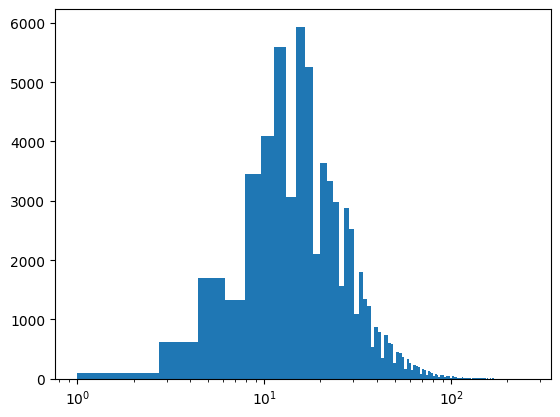

In [64]:
plt.hist(title_lengts, bins=150)
plt.semilogx()
plt.show()

In [65]:
title_lengts.mean()

np.float64(23.896672990606636)

In [66]:
title_lengts.std()

np.float64(16.903414622685126)

In [67]:
title_lengts[(title_lengts > (23-16)) & (title_lengts < (23+16))]

1         9
3        14
4        19
5         8
6        12
         ..
64828    21
64829    24
64830    17
64831    24
64832    31
Name: title, Length: 52418, dtype: int64

In [68]:
title_lengts[(title_lengts > (23-16)) & (title_lengts < (23+16))] / len(title_lengts)

1        0.000139
3        0.000216
4        0.000293
5        0.000123
6        0.000185
           ...   
64828    0.000324
64829    0.000370
64830    0.000262
64831    0.000370
64832    0.000478
Name: title, Length: 52418, dtype: float64

In [70]:
lower_bound = title_lengts.mean() - 2 * title_lengts.std()
upper_bound = title_lengts.mean() + 2 * title_lengts.std()
len(title_lengts[(title_lengts > lower_bound) & (title_lengts < upper_bound)]) / len(title_lengts)

0.9527863896472475

In [72]:
manga_data.title.str.contains(":", regex=False)

0        False
1        False
2         True
3        False
4        False
         ...  
64828    False
64829    False
64830    False
64831    False
64832    False
Name: title, Length: 64833, dtype: bool

In [74]:
manga_data[manga_data.title.str.contains(":", regex=False)].title.sort_values()

39326    "Chikatetsu ni Noru" Series: Kyo Girls Days - ...
37070    "Ecchi shitai" to Itte Kure: Seijin(?) Buchou ...
7704       "Fushigi" Toriatsukaimasu: Tsukumodou Kottouten
46361    "Hora, Ore no Ue ni Matagare yo": Gouman Joush...
56643    "Jimi de Tsumaranai" to Suterareta node, Jimic...
                               ...                        
29202                        α no Hanayome: Kyoumei Renjou
37966                 †Ankoku Datsui†: Kaichou to Kuro Gal
56431               √4: Uchi no Juunin wa Minna Ijou desu.
55739               ○×△ Base: Nettori Guchagucha Celluloid
8749                                ♭38℃: Loveberry Twins♥
Name: title, Length: 8590, dtype: str

In [75]:
8749 / len(manga_data)

0.13494670923757962

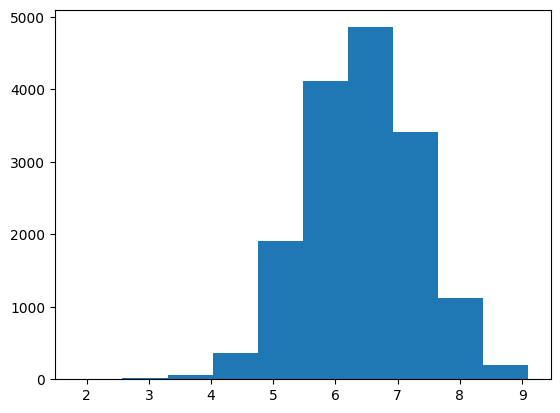

In [76]:
plt.hist(anime_data.score)
plt.show()

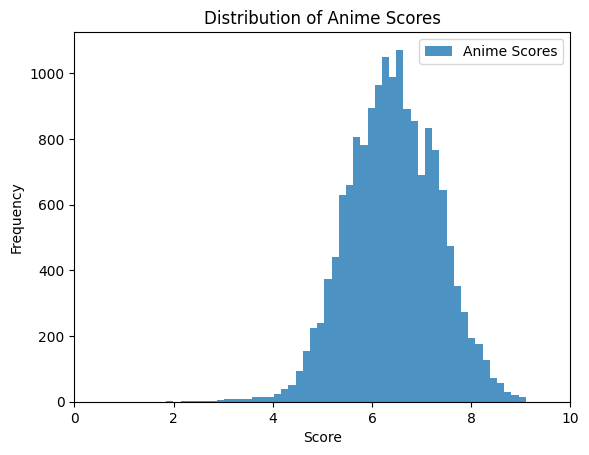

In [83]:
plt.hist(anime_data.score, bins=50, alpha=0.8, label='Anime Scores')
plt.xlim(0, 10)
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.title('Distribution of Anime Scores')
plt.legend()
plt.show()

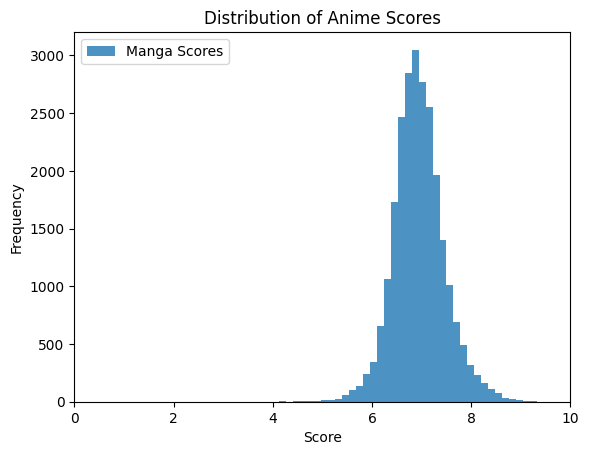

In [82]:
plt.hist(manga_data.score, bins=50, alpha=0.8, label='Manga Scores')
plt.xlim(0, 10)
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.title('Distribution of Anime Scores')
plt.legend()
plt.show()

In [84]:
anime_data.score.std(), manga_data.score.std()

(np.float64(0.8993046454214529), np.float64(0.5201697709851325))

In [85]:
manga_data.score.mean(), anime_data.score.mean()  

(np.float64(6.9451790063321965), np.float64(6.418469781931465))

In [86]:
manga_data.columns

Index(['manga_id', 'title', 'type', 'score', 'scored_by', 'status', 'volumes',
       'chapters', 'start_date', 'end_date', 'members', 'favorites', 'sfw',
       'approved', 'created_at_before', 'updated_at', 'real_start_date',
       'real_end_date', 'genres', 'themes', 'demographics', 'authors',
       'serializations', 'synopsis', 'background', 'main_picture', 'url',
       'title_english', 'title_japanese', 'title_synonyms'],
      dtype='str')

In [91]:
anime_data.score

0        9.10
1        9.04
2        9.05
3        9.07
4        8.94
         ... 
24980     NaN
24981     NaN
24982     NaN
24983     NaN
24984     NaN
Name: score, Length: 24985, dtype: float64

In [92]:
anime_data.scored_by

0        2037075
1        1671587
2        1491491
3        1348232
4        1540277
          ...   
24980         10
24981          2
24982          2
24983          1
24984          0
Name: scored_by, Length: 24985, dtype: int64

C:\Users\PC\AppData\Local\Temp\ipykernel_29688\3186307704.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


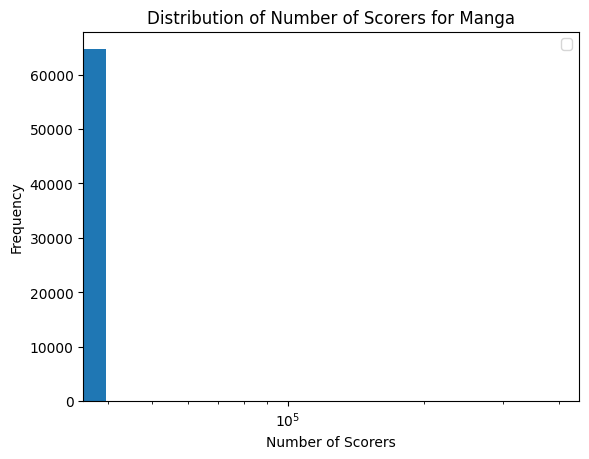

In [89]:
plt.hist(manga_data.scored_by)
plt.xlabel('Number of Scorers')
plt.ylabel('Frequency') 
plt.title('Distribution of Number of Scorers for Manga')
plt.legend()
plt.semilogx()
plt.show()

C:\Users\PC\AppData\Local\Temp\ipykernel_29688\1185107200.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


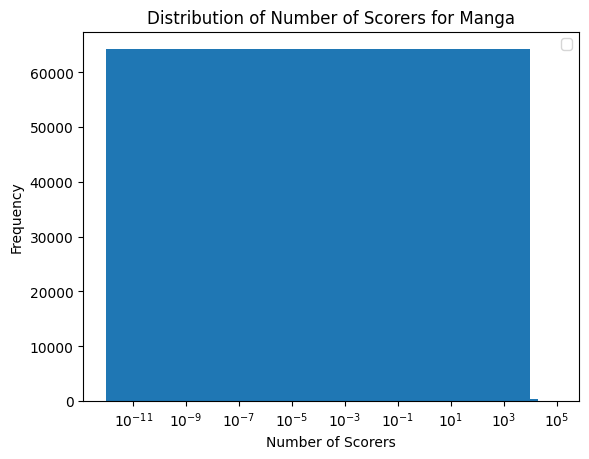

In [90]:
plt.hist(manga_data.scored_by[manga_data.scored_by < 1e5])
plt.xlabel('Number of Scorers')
plt.ylabel('Frequency') 
plt.title('Distribution of Number of Scorers for Manga')
plt.legend()
plt.semilogx()
plt.show()

In [93]:
pd.qcut(anime_data.scored_by, 10).value_counts().sort_index()

scored_by
(-0.001, 10.0]          2724
(10.0, 31.0]            2302
(31.0, 75.0]            2486
(75.0, 146.6]           2482
(146.6, 307.0]          2508
(307.0, 782.0]          2490
(782.0, 2077.0]         2498
(2077.0, 6086.2]        2498
(6086.2, 28858.8]       2498
(28858.8, 2685033.0]    2499
Name: count, dtype: int64

In [94]:
pd.qcut(manga_data.scored_by, 10).value_counts().sort_index()

scored_by
(-0.001, 3.0]        8649
(3.0, 5.0]           4783
(5.0, 10.0]          6252
(10.0, 22.0]         6413
(22.0, 46.0]         6492
(46.0, 90.0]         6382
(90.0, 182.0]        6435
(182.0, 385.0]       6470
(385.0, 994.0]       6477
(994.0, 394362.0]    6480
Name: count, dtype: int64

In [95]:
anime_stable_rating = anime_data[anime_data.scored_by > 10]
manga_stable_rating = manga_data[manga_data.scored_by > 10]

In [96]:
len(anime_stable_rating), len(manga_stable_rating)

(22261, 45149)

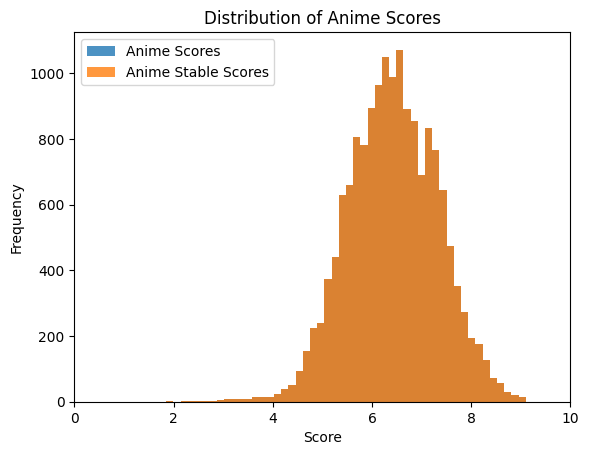

In [97]:
plt.hist(anime_data.score, bins=50, alpha=0.8, label='Anime Scores')
plt.hist(anime_stable_rating.score, bins=50, alpha=0.8, label='Anime Stable Scores')
plt.xlim(0, 10)
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.title('Distribution of Anime Scores')
plt.legend()
plt.show()
plt.show()

In [98]:
len(anime_stable_rating) / len(anime_data)

0.8909745847508506

In [99]:
len(manga_stable_rating) / len(manga_data)  

0.6963891845202289

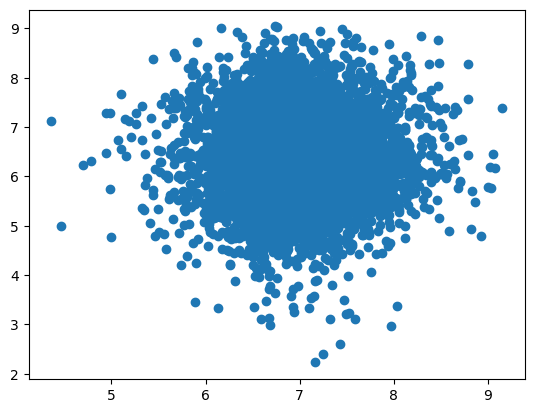

In [100]:
plt.scatter(manga_data.score.sample(len(anime_data)), anime_data.score)

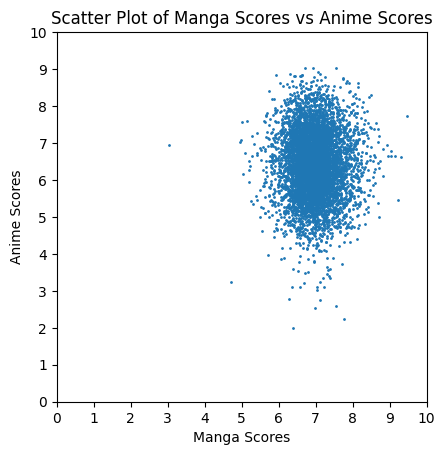

In [101]:
plt.scatter(manga_data.score.sample(len(anime_data)), anime_data.score, s=1)
plt.xlabel('Manga Scores')
plt.ylabel('Anime Scores')
plt.title('Scatter Plot of Manga Scores vs Anime Scores')
plt.xticks(range(11))
plt.yticks(range(11))
plt.gca().set_aspect('equal', adjustable='box')
plt.show()

In [102]:
manga_data.merge(anime_data, on='title', suffixes=['_m', '_a'])   

,manga_id,title,type_m,score_m,scored_by_m,status_m,volumes,chapters,start_date_m,end_date_m,...,producers,licensors,synopsis_a,background_a,main_picture_a,url_a,trailer_url,title_english_a,title_japanese_a,title_synonyms_a
0,2,Berserk,manga,9.47,319696,currently_publishing,NaN,NaN,1989-08-25,NaN,...,"['WOWOW', 'Mainichi Broadcasting System', 'Hak...","['Funimation', 'Crunchyroll']",Now branded for death and destined to be hunte...,NaN,https://cdn.myanimelist.net/images/anime/10/79...,https://myanimelist.net/anime/32379/Berserk,https://www.youtube.com/watch?v=XQr7LvFZrlE,Berserk (2016),ベルセルク,[]
1,13,One Piece,manga,9.22,355375,currently_publishing,NaN,NaN,1997-07-22,NaN,...,"['Fuji TV', 'TAP', 'Shueisha']","['Funimation', '4Kids Entertainment']",Barely surviving in a barrel after passing thr...,Several anime-original arcs have been adapted ...,https://cdn.myanimelist.net/images/anime/6/732...,https://myanimelist.net/anime/21/One_Piece,https://www.youtube.com/watch?v=l_98K4_6UQ0,One Piece,ONE PIECE,['OP']
2,25,Fullmetal Alchemist,manga,9.03,153151,finished,27.0,116.0,2001-07-12,2010-09-11,...,"['Aniplex', 'Dentsu', 'Square Enix', 'Mainichi...","['Funimation', 'Aniplex of America']","Edward Elric, a young, brilliant alchemist, ha...",Fullmetal Alchemist won the TV Feature Award i...,https://cdn.myanimelist.net/images/anime/10/75...,https://myanimelist.net/anime/121/Fullmetal_Al...,https://www.youtube.com/watch?v=NR5HHcLPulc,Fullmetal Alchemist,鋼の錬金術師,"['Hagane no Renkinjutsushi', 'FMA', 'Full Meta..."
3,642,Vinland Saga,manga,9.05,119797,currently_publishing,NaN,NaN,2005-04-13,NaN,...,"['Production I.G', 'Dentsu', 'Kodansha', 'Twin...",['Sentai Filmworks'],Young Thorfinn grew up listening to the storie...,NaN,https://cdn.myanimelist.net/images/anime/1500/...,https://myanimelist.net/anime/37521/Vinland_Saga,https://www.youtube.com/watch?v=f8JrZ7Q_p-8,NaN,ヴィンランド・サガ,[]
4,90125,Kaguya-sama wa Kokurasetai: Tensai-tachi no Re...,manga,8.92,123341,finished,28.0,281.0,2015-05-19,2022-11-02,...,"['Aniplex', 'Mainichi Broadcasting System', 'M...",['Aniplex of America'],"At the renowned Shuchiin Academy, Miyuki Shiro...",NaN,https://cdn.myanimelist.net/images/anime/1295/...,https://myanimelist.net/anime/37999/Kaguya-sam...,https://www.youtube.com/watch?v=Ti2kJ-GYO68,Kaguya-sama: Love is War,かぐや様は告らせたい～天才たちの恋愛頭脳戦～,"[""Kaguya Wants to be Confessed To: The Geniuse..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3912,127215,Gravitation,doujinshi,NaN,3,finished,1.0,4.0,1996-08-04,1996-08-04,...,['Aniplex'],['Nozomi Entertainment'],All Shuichi ever dreamed about was following i...,Gravitation follows the manga adaptation close...,https://cdn.myanimelist.net/images/anime/4/218...,https://myanimelist.net/anime/243/Gravitation,NaN,Gravitation,グラビテーション,[]
3913,146430,Wagahai wa Neko de Aru,manga,NaN,2,finished,1.0,7.0,2010-09-10,2010-09-10,...,['Fuji TV'],[],"""I"" is a cat without a name who lives with an ...",NaN,https://cdn.myanimelist.net/images/anime/11/53...,https://myanimelist.net/anime/20145/Wagahai_wa...,NaN,NaN,吾輩は猫である,['I Am a Cat']
3914,117400,Genma Taisen: Shinwa Zenya no Shou,manga,NaN,1,finished,4.0,18.0,1979-03-01,1981-09-01,...,['KENMedia'],['Media Blasters'],"In the distant future, monsters and inhumans r...",NaN,https://cdn.myanimelist.net/images/anime/1/170...,https://myanimelist.net/anime/1705/Genma_Taise...,NaN,Genma Wars,幻魔大戦－神話前夜の章,"['Genma Taisen', 'Genma Wars: Eve of Mythology..."
3915,146574,Contact,one_shot,NaN,1,finished,NaN,1.0,2021-08-25,2021-08-25,...,[],[],A Backkom short about him meeting an alien.,NaN,https://cdn.myanimelist.net/images/anime/2/657...,https://myanimelist.net/anime/25985/Contact,NaN,Contact,Contact,"['Backkom', 'Bernard']"


In [103]:
same_titles = manga_data.merge(anime_data, on='title', suffixes=['_m', '_a']).sort_values('title')

In [104]:
for row in manga_data.iterrows():
    print(row)  
    break

(0, manga_id                                                             2
title                                                          Berserk
type                                                             manga
score                                                             9.47
scored_by                                                       319696
status                                            currently_publishing
volumes                                                            NaN
chapters                                                           NaN
start_date                                                  1989-08-25
end_date                                                           NaN
members                                                         643969
favorites                                                       119470
sfw                                                               True
approved                                                          True
cr

In [105]:
for i, row in manga_data.iterrows():
    print(row.title_synonyms)  
    break

['Berserk: The Prototype']


In [110]:
for i, row in manga_data.iterrows():
    synonyms = row.title_synonyms
    for synonym:
        for ... in manga_data.iterrows():
    if i > 20:
         break

SyntaxError: invalid syntax (1123655373.py, line 3)

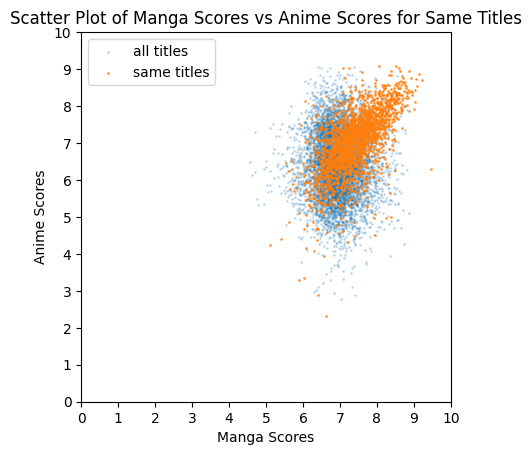

In [120]:
plt.scatter(manga_data.score.sample(len(anime_data), random_state=46464), anime_data.score, s=1, alpha=0.2, label='all titles')
plt.scatter(same_titles.score_m, same_titles.score_a, s=1, alpha=0.7, label='same titles')
plt.xlabel('Manga Scores')
plt.ylabel('Anime Scores')  
plt.title('Scatter Plot of Manga Scores vs Anime Scores for Same Titles')
plt.legend()
plt.xticks(range(11))
plt.yticks(range(11))
plt.gca().set_aspect('equal', adjustable='box')
plt.show()

In [117]:
same_titles[['score_m', 'score_a']].corr()  

,score_m,score_a
score_m,1.000000,0.625913
score_a,0.625913,1.000000


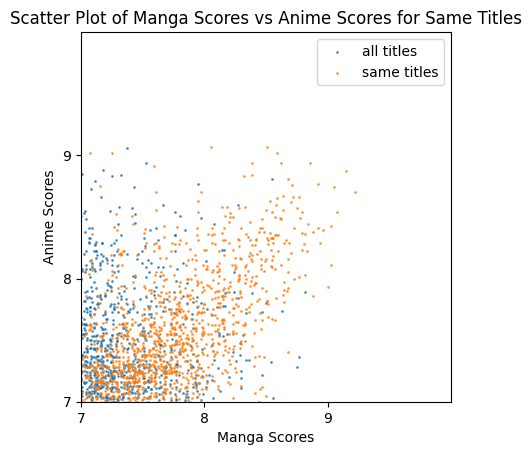

In [118]:
plt.scatter(manga_data.score.sample(len(anime_data), random_state=46464), anime_data.score, s=1, alpha=0.7, label='all titles')
plt.scatter(same_titles.score_m, same_titles.score_a, s=1, alpha=0.7, label='same titles')
plt.xlabel('Manga Scores')
plt.ylabel('Anime Scores')  
plt.title('Scatter Plot of Manga Scores vs Anime Scores for Same Titles')
plt.legend()
plt.xticks(range(7, 10))
plt.yticks(range(7, 10))
plt.xlim(7, 10)
plt.ylim(7, 10) 
plt.gca().set_aspect('equal', adjustable='box')
plt.show()

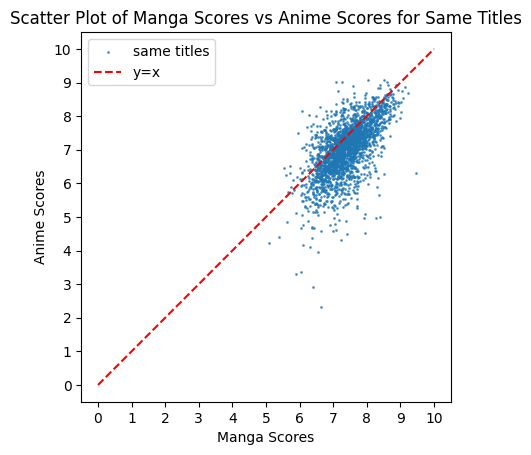

In [119]:
plt.scatter(same_titles.score_m, same_titles.score_a, s=1, alpha=0.7, label='same titles')
plt.plot([0, 10], [0, 10], color='red', linestyle='--', label='y=x')
plt.xlabel('Manga Scores')
plt.ylabel('Anime Scores')
plt.title('Scatter Plot of Manga Scores vs Anime Scores for Same Titles')
plt.legend()
plt.xticks(range(11))
plt.yticks(range(11))
plt.gca().set_aspect('equal', adjustable='box')
plt.show()

In [123]:
manga_data[manga_data.score >=9]

,manga_id,title,type,score,scored_by,status,volumes,chapters,start_date,end_date,...,demographics,authors,serializations,synopsis,background,main_picture,url,title_english,title_japanese,title_synonyms
0,2,Berserk,manga,9.47,319696,currently_publishing,NaN,NaN,1989-08-25,NaN,...,['Seinen'],"[{'id': 1868, 'first_name': 'Kentarou', 'last_...",['Young Animal'],"Guts, a former mercenary now known as the ""Bla...",Berserk won the Award for Excellence at the si...,https://cdn.myanimelist.net/images/manga/1/157...,https://myanimelist.net/manga/2/Berserk,Berserk,ベルセルク,['Berserk: The Prototype']
1,13,One Piece,manga,9.22,355375,currently_publishing,NaN,NaN,1997-07-22,NaN,...,['Shounen'],"[{'id': 1881, 'first_name': 'Eiichiro', 'last_...",['Shounen Jump (Weekly)'],"Gol D. Roger, a man referred to as the ""King o...",One Piece is the highest selling manga series ...,https://cdn.myanimelist.net/images/manga/2/253...,https://myanimelist.net/manga/13/One_Piece,One Piece,ONE PIECE,[]
2,1706,JoJo no Kimyou na Bouken Part 7: Steel Ball Run,manga,9.30,151433,finished,24.0,96.0,2004-01-19,2011-04-19,...,"['Seinen', 'Shounen']","[{'id': 2619, 'first_name': 'Hirohiko', 'last_...",['Ultra Jump'],"In the American Old West, the world's greatest...",JoJo no Kimyou na Bouken Part 7: Steel Ball Ru...,https://cdn.myanimelist.net/images/manga/3/179...,https://myanimelist.net/manga/1706/JoJo_no_Kim...,NaN,ジョジョの奇妙な冒険 Part7 STEEL BALL RUN,"[""JoJo's Bizarre Adventure Part 7: Steel Ball ..."
3,4632,Oyasumi Punpun,manga,9.02,168459,finished,13.0,147.0,2007-03-15,2013-11-02,...,['Seinen'],"[{'id': 2836, 'first_name': 'Inio', 'last_name...",['Big Comic Spirits'],Punpun Onodera is a normal 11-year-old boy liv...,Oyasumi Punpun was originally serialized in Yo...,https://cdn.myanimelist.net/images/manga/3/266...,https://myanimelist.net/manga/4632/Oyasumi_Punpun,Goodnight Punpun,おやすみプンプン,[]
4,25,Fullmetal Alchemist,manga,9.03,153151,finished,27.0,116.0,2001-07-12,2010-09-11,...,['Shounen'],"[{'id': 1874, 'first_name': 'Hiromu', 'last_na...",['Shounen Gangan'],Alchemists are knowledgeable and naturally tal...,Hagane no Renkinjutsushi won the 49th Shogakuk...,https://cdn.myanimelist.net/images/manga/3/243...,https://myanimelist.net/manga/25/Fullmetal_Alc...,Fullmetal Alchemist,鋼の錬金術師,"['Full Metal Alchemist', 'Hagane no Renkinjuts..."
5,656,Vagabond,manga,9.24,129688,on_hiatus,37.0,327.0,1998-09-03,2015-05-21,...,['Seinen'],"[{'id': 1911, 'first_name': 'Takehiko', 'last_...",['Morning'],"In 16th-century Japan, Shinmen Takezou is a wi...","In 2000, Vagabond won the Japan Media Arts Fes...",https://cdn.myanimelist.net/images/manga/1/259...,https://myanimelist.net/manga/656/Vagabond,Vagabond,バガボンド,[]
6,642,Vinland Saga,manga,9.05,119797,currently_publishing,NaN,NaN,2005-04-13,NaN,...,['Seinen'],"[{'id': 2034, 'first_name': 'Makoto', 'last_na...",['Afternoon'],"Thorfinn, son of one of the Vikings' greatest ...",Vinland Saga won the 13th Japan Media Arts Awa...,https://cdn.myanimelist.net/images/manga/2/188...,https://myanimelist.net/manga/642/Vinland_Saga,Vinland Saga,ヴィンランド・サガ,[]
9,1,Monster,manga,9.15,90296,finished,18.0,162.0,1994-12-05,2001-12-20,...,['Seinen'],"[{'id': 1867, 'first_name': 'Naoki', 'last_nam...",['Big Comic Original'],"Kenzou Tenma, a renowned Japanese neurosurgeon...",Monster won the Grand Prize at the 3rd annual ...,https://cdn.myanimelist.net/images/manga/3/258...,https://myanimelist.net/manga/1/Monster,Monster,MONSTER,[]
16,51,Slam Dunk,manga,9.08,70877,finished,31.0,276.0,1990-09-18,1996-06-04,...,['Shounen'],"[{'id': 1911, 'first_name': 'Takehiko', 'last_...",['Shounen Jump (Weekly)'],"Hanamichi Sakuragi, a tall, boisterous teenage...",Slam Dunk was awarded the 40th Shogakukan Mang...,https://cdn.myanimelist.net/images/manga/2/258...,https://myanimelist.net/manga/51/Slam_Dunk,Slam Dunk,SLAM DUNK,[]
18,70345,Grand Blue,manga,9.03,63438,currently_publishing,NaN,NaN,2014-04-07,NaN,...,['Seinen'],"[{'id': 7108, 'first_name': 'Kenji', 'last_nam...",[

In [124]:
same_titles[same_titles.score_m >= 9].sort_values('score_m')[['title', 'score_m', 'score_a']]

,title,score_m,score_a
13,Kingdom,9.00,7.93
2,Fullmetal Alchemist,9.03,8.11
12,Grand Blue,9.03,8.43
3,Vinland Saga,9.05,8.74
10,Slam Dunk,9.08,8.54
6,Monster,9.15,8.87
1,One Piece,9.22,8.70
0,Berserk,9.47,6.31


In [125]:
highly_rated = same_titles[same_titles.score_m >= 9].sort_values('score_m')[['title', 'score_m', 'score_a']]    
highly_rated["diff"] = np.abs(highly_rated.score_m - highly_rated.score_a)
highly_rated

,title,score_m,score_a,diff
13,Kingdom,9.00,7.93,1.07
2,Fullmetal Alchemist,9.03,8.11,0.92
12,Grand Blue,9.03,8.43,0.60
3,Vinland Saga,9.05,8.74,0.31
10,Slam Dunk,9.08,8.54,0.54
6,Monster,9.15,8.87,0.28
1,One Piece,9.22,8.70,0.52
0,Berserk,9.47,6.31,3.16


In [127]:
same_titles[same_titles.score_m > same_titles.score_a]

,manga_id,title,type_m,score_m,scored_by_m,status_m,volumes,chapters,start_date_m,end_date_m,...,producers,licensors,synopsis_a,background_a,main_picture_a,url_a,trailer_url,title_english_a,title_japanese_a,title_synonyms_a
1103,117,.hack//Tasogare no Udewa Densetsu,manga,7.04,9760,finished,3.0,24.0,2001-12-10,2003-10-10,...,"['Bandai Visual', 'Yomiko Advertising']","['Funimation', 'Bandai Entertainment']","Winning the legendary characters ""Kite"" and ""B...",NaN,https://cdn.myanimelist.net/images/anime/4/783...,https://myanimelist.net/anime/298/hack__Tasoga...,NaN,.hack//Legend of The Twilight,.hack//黄昏の腕輪伝説,"['.hack//Udeden', '.hack//Legend of the Twilig..."
2202,42755,009 Re:Cyborg,manga,6.84,279,finished,6.0,35.0,2012-05-25,2015-09-25,...,"['Nippon Television Network', 'Ishimori Pro']","['Funimation', 'NYAV Post']",Nine regular humans from different parts of th...,Winner of the Platinum Grand Prize during the ...,https://cdn.myanimelist.net/images/anime/9/401...,https://myanimelist.net/anime/11755/009_Re_Cyborg,https://www.youtube.com/watch?v=F1hdch-i1Wg,NaN,009 RE:CYBORG,[]
276,1349,07-Ghost,manga,7.92,13550,finished,17.0,100.0,2005-04-28,2013-08-28,...,['Ichijinsha'],['Discotek Media'],Barsburg Empire's Military Academy is known fo...,NaN,https://cdn.myanimelist.net/images/anime/3/226...,https://myanimelist.net/anime/5525/07-Ghost,https://www.youtube.com/watch?v=vRjlJDDfhJI,07-Ghost,セブンゴースト,"['07 Ghost', 'Seven Ghost', '7 Ghosts', 'The S..."
1315,844,1 Pound no Fukuin,manga,7.18,1008,finished,4.0,37.0,1987-07-24,2006-12-21,...,[],['VIZ Media'],"Hatanaka Kosaku, a hopeful boxer, has a mean K...",NaN,https://cdn.myanimelist.net/images/anime/1577/...,https://myanimelist.net/anime/1328/1_Pound_no_...,NaN,One Pound Gospel,１ポンドの福音,['Ichi Pound no Fukuin']
2600,58137,1+2=Paradise,manga,6.11,110,finished,5.0,25.0,1988-10-06,1990-11-06,...,['Agent 21'],[],Yuusuke Yamamoto has a crippling phobia of wom...,NaN,https://cdn.myanimelist.net/images/anime/2/367...,https://myanimelist.net/anime/2730/1_2_Paradise,NaN,NaN,１＋２＝パラダイス,[]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1143,191,Zipang,manga,7.59,721,finished,43.0,422.0,2000-07-27,2009-11-05,...,"['Marvelous', 'TBS']",['Geneon Entertainment USA'],"Mirai, an improved Kongou-class Aegis guided m...",NaN,https://cdn.myanimelist.net/images/anime/13/75...,https://myanimelist.net/anime/29/Zipang,NaN,NaN,ジパング,[]
745,99,Zombie-Loan,manga,7.35,6871,finished,13.0,83.0,2002-10-18,2011-02-18,...,"['Xebec', 'Nihon Ad Systems']",['Discotek Media'],Do you know when you are going to die? Michiru...,NaN,https://cdn.myanimelist.net/images/anime/2/215...,https://myanimelist.net/anime/2404/Zombie-Loan,NaN,Zombie-Loan,ZOMBIE-LOAN ゾンビローン,[]
2399,89549,Zutto Suki Datta,manga,6.50,309,finished,1.0,7.0,2013-06-05,2016-08-05,...,['Mediabank'],[],Setsuna Shiraha has loved her childhood friend...,NaN,https://cdn.myanimelist.net/images/anime/1498/...,https://myanimelist.net/anime/34895/Zutto_Suki...,NaN,NaN,ずっと好きだった,[]
80,10,xxxHOLiC,manga,8.38,31602,finished,19.0,213.0,2003-02-24,2011-02-09,...,"['TBS', 'BMG Japan', 'Kids Station', 'Kodansha...",['Funimation'],Kimihiro Watanuki can see spirits and other as...,NaN,https://cdn.myanimelist.net/images/anime/5/218...,https://myanimelist.net/anime/861/xxxHOLiC,https://www.youtube.com/watch?v=zOoZgS7eiBg,xxxHOLiC,×××HOLiC（ホリック）,[]


In [128]:
same_titles[same_titles.score_m < same_titles.score_a]

,manga_id,title,type_m,score_m,scored_by_m,status_m,volumes,chapters,start_date_m,end_date_m,...,producers,licensors,synopsis_a,background_a,main_picture_a,url_a,trailer_url,title_english_a,title_japanese_a,title_synonyms_a
20,126146,"""Oshi no Ko""",manga,8.68,58169,currently_publishing,NaN,NaN,2020-04-23,NaN,...,"['Shueisha', 'CyberAgent', 'Kadokawa']",['Sentai Filmworks'],"In the entertainment world, celebrities often ...",NaN,https://cdn.myanimelist.net/images/anime/1812/...,https://myanimelist.net/anime/52034/Oshi_no_Ko,https://www.youtube.com/watch?v=1yXa8MAmocQ,[Oshi No Ko],【推しの子】,['My Star']
2414,82899,15 Bishoujo Hyouryuuki,manga,6.75,171,finished,1.0,10.0,2012-06-21,2013-05-02,...,['HoriPro'],[],"After a heavy storm, Kazuma Shiraishi finds hi...",NaN,https://cdn.myanimelist.net/images/anime/13/31...,https://myanimelist.net/anime/5762/15_Bishoujo...,NaN,NaN,15美少女漂流記,['The Story of 15 Beautiful Girls Adrift']
2491,55783,30-sai no Hoken Taiiku,manga,6.36,239,finished,2.0,11.0,2010-10-27,2011-08-27,...,[],[],Based on Mitsuba and Ichijinsha's 30-sai no Ho...,NaN,https://cdn.myanimelist.net/images/anime/2/811...,https://myanimelist.net/anime/9624/30-sai_no_H...,https://www.youtube.com/watch?v=N1FSHkgVgt0,A Thirty-Year Old's Health and Physical Education,30歳の保健体育,['Sanjuu-sai no Hoken Taiiku']
954,112236,86,manga,7.59,1155,currently_publishing,NaN,NaN,2018-02-16,NaN,...,"['Aniplex', 'Kadokawa', 'Bandai Spirits']",[],"According to the Republic of San Magnolia, the...",NaN,https://cdn.myanimelist.net/images/anime/1987/...,https://myanimelist.net/anime/41457/86,https://www.youtube.com/watch?v=WVegRUOgkPM,86 Eighty-Six,86―エイティシックス―,['Eighty Six']
1087,53539,ACCA: 13-ku Kansatsu-ka,manga,7.51,893,finished,6.0,37.0,2013-06-25,2016-10-25,...,"['Bandai Visual', 'Square Enix', 'Lantis', 'Ni...",['Funimation'],ACCA—a national body of the kingdom of Dowa th...,NaN,https://cdn.myanimelist.net/images/anime/3/837...,https://myanimelist.net/anime/33337/ACCA__13-k...,https://www.youtube.com/watch?v=9KLcXHQZyls,ACCA: 13-Territory Inspection Dept.,ACCA 13区監察課,"['ACCA: 13th Territory Inspection Department',..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2116,2987,Zetman,manga,6.31,1228,finished,1.0,4.0,1989-07-04,1994-12-27,...,"['TV Asahi', 'Asatsu DK', 'YTV', 'Toho', 'Saku...","['VIZ Media', 'NYAV Post']",The story starts off with a face-off between t...,NaN,https://cdn.myanimelist.net/images/anime/1955/...,https://myanimelist.net/anime/11837/Zetman,https://www.youtube.com/watch?v=2POvUa8qpq8,Zetman,ゼットマン,[]
364,15205,Zetsuen no Tempest,manga,7.90,6726,finished,10.0,50.0,2009-07-10,2013-10-12,...,"['Aniplex', 'Dentsu', 'Square Enix', 'Mainichi...",['Aniplex of America'],"Yoshino Takigawa, an ordinary teenager, is sec...",Zetsuen no Tempest draws heavily on two Shakes...,https://cdn.myanimelist.net/images/anime/7/424...,https://myanimelist.net/anime/14075/Zetsuen_no...,https://www.youtube.com/watch?v=xP78R0b70yE,Blast of Tempest,絶園のテンペスト,['Zetsuen no Tempest: The Civilization Blaster']
490,122392,Zom 100: Zombie ni Naru made ni Shitai 100 no ...,manga,7.61,9621,currently_publishing,NaN,NaN,2018-10-19,NaN,...,"['Shogakukan-Shueisha Productions', 'dugout']",['VIZ Media'],"In a trash-filled apartment, 24-year-old Akira...",The anime is part of a production deal between...,https://cdn.myanimelist.net/images/anime/1384/...,https://myanimelist.net/anime/54112/Zom_100__Z...,https://www.youtube.com/watch?v=GAMrUx-esS8,Zom 100: Bucket List of the Dead,ゾン100～ゾンビになるまでにしたい100のこと～,"['Bucket List of The Dead, Zombie 100: 100 Thi..."
2409,116028,Zombieland Saga,manga,6.79,160,currently_publishing,NaN,NaN,2018-10-08,NaN,...,"['Avex Pictures', 'Cygames', 'dugout']",['Funimation'],Sakura Minamoto dreams of becoming an idol. Un...,Zombieland Saga is an original anime productio...,https://cdn.myanimelist.net/images/anime/1084/...,https://myanimelist.net/anime/37976/Zombieland...,https://www.youtube.com/watch?v=O3VO4z

In [129]:
manga_data.real_start_date

0        1989-08-25
1        1997-07-22
2        2004-01-19
3        2007-03-15
4        2001-07-12
            ...    
64828    2018-08-30
64829    2013-01-19
64830    2021-08-02
64831    2022-03-03
64832    2020-01-24
Name: real_start_date, Length: 64833, dtype: str

In [130]:
pd.to_datetime(manga_data.real_start_date, format='mixed')

0       1989-08-25
1       1997-07-22
2       2004-01-19
3       2007-03-15
4       2001-07-12
           ...    
64828   2018-08-30
64829   2013-01-19
64830   2021-08-02
64831   2022-03-03
64832   2020-01-24
Name: real_start_date, Length: 64833, dtype: datetime64[us]

In [138]:
manga_data_real_start_date = pd.to_datetime(manga_data.real_start_date, format='mixed')

In [132]:
manga_data.start_date.str.split("-", expand=True)

,0,1,2
0,1989,08,25
1,1997,07,22
2,2004,01,19
3,2007,03,15
4,2001,07,12
...,...,...,...
64828,2018,08,30
64829,2013,01,19
64830,2021,08,02
64831,2022,03,03


In [133]:
date_parts = manga_data.start_date.str.split("-", expand=True)

In [134]:
date_parts[date_parts[2].isna()]

,0,1,2
941,NaN,NaN,NaN
2147,NaN,NaN,NaN
2333,NaN,NaN,NaN
2471,NaN,NaN,NaN
2608,NaN,NaN,NaN
...,...,...,...
61395,NaN,NaN,NaN
61724,NaN,NaN,NaN
62006,NaN,NaN,NaN
62013,NaN,NaN,NaN


(array([5.0000e+00, 3.0000e+00, 4.9000e+01, 8.2000e+01, 3.7700e+02,
        5.7600e+02, 2.0270e+03, 6.3260e+03, 2.6304e+04, 2.7201e+04]),
 array([1928. , 1937.5, 1947. , 1956.5, 1966. , 1975.5, 1985. , 1994.5,
        2004. , 2013.5, 2023. ]),
 <BarContainer object of 10 artists>)

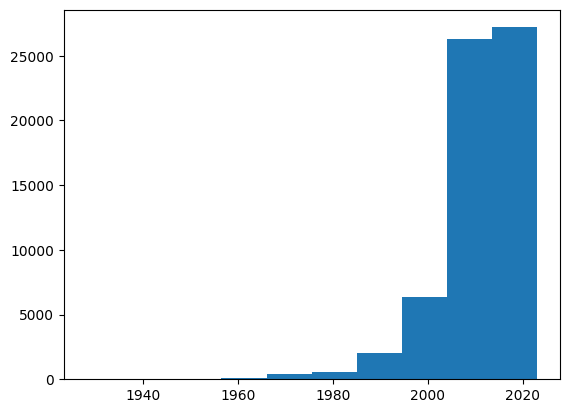

In [142]:
plt.hist(manga_data.real_start_date.dt.year)

In [141]:
manga_data.real_start_date = pd.to_datetime(manga_data.real_start_date, format='mixed')

(array([1.000e+00, 2.000e+00, 0.000e+00, 2.000e+00, 0.000e+00, 0.000e+00,
        1.000e+00, 0.000e+00, 0.000e+00, 2.000e+00, 8.000e+00, 9.000e+00,
        1.100e+01, 1.200e+01, 9.000e+00, 1.300e+01, 1.600e+01, 1.800e+01,
        1.800e+01, 1.700e+01, 5.100e+01, 5.800e+01, 8.500e+01, 8.200e+01,
        1.010e+02, 8.900e+01, 1.120e+02, 1.320e+02, 1.600e+02, 8.300e+01,
        2.400e+02, 3.240e+02, 3.890e+02, 4.670e+02, 6.070e+02, 7.940e+02,
        1.032e+03, 1.387e+03, 1.872e+03, 1.241e+03, 3.267e+03, 4.372e+03,
        5.450e+03, 6.145e+03, 7.070e+03, 7.534e+03, 7.074e+03, 5.306e+03,
        4.971e+03, 2.316e+03]),
 array([1928. , 1929.9, 1931.8, 1933.7, 1935.6, 1937.5, 1939.4, 1941.3,
        1943.2, 1945.1, 1947. , 1948.9, 1950.8, 1952.7, 1954.6, 1956.5,
        1958.4, 1960.3, 1962.2, 1964.1, 1966. , 1967.9, 1969.8, 1971.7,
        1973.6, 1975.5, 1977.4, 1979.3, 1981.2, 1983.1, 1985. , 1986.9,
        1988.8, 1990.7, 1992.6, 1994.5, 1996.4, 1998.3, 2000.2, 2002.1,
        2004. , 

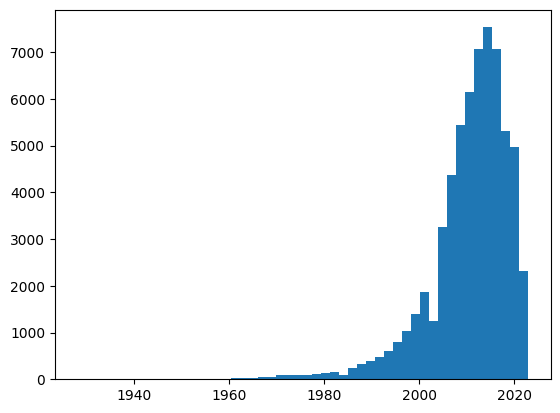

In [143]:
plt.hist(manga_data.real_start_date.dt.year, bins=50)

In [146]:
manga_data[(manga_data.real_start_date.dt.year >= 2020) & (manga_data.real_start_date.dt.year < 2023) ]

,manga_id,title,type,score,scored_by,status,volumes,chapters,start_date,end_date,...,demographics,authors,serializations,synopsis,background,main_picture,url,title_english,title_japanese,title_synonyms
26,145863,Sayonara Eri,manga,8.70,60899,finished,1.0,NaN,2022-04-11,2022-04-11,...,['Shounen'],"[{'id': 41158, 'first_name': 'Tatsuki', 'last_...",['Shounen Jump+'],"Suffering from a terminal illness, Yuuta's mot...",Sayonara Eri was published digitally as an Eng...,https://cdn.myanimelist.net/images/manga/3/263...,https://myanimelist.net/manga/145863/Sayonara_Eri,"Goodbye, Eri",さよなら絵梨,[]
30,126146,"""Oshi no Ko""",manga,8.68,58169,currently_publishing,NaN,NaN,2020-04-23,NaN,...,['Seinen'],"[{'id': 2139, 'first_name': 'Aka', 'last_name'...",['Young Jump'],Sixteen-year-old Ai Hoshino is a talented and ...,"""Oshi no Ko"" has been published digitally in E...",https://cdn.myanimelist.net/images/manga/3/233...,https://myanimelist.net/manga/126146/Oshi_no_Ko,[Oshi No Ko],【推しの子】,"['My Star', '【Oshi no Ko】']"
74,138673,Look Back,manga,8.38,52661,finished,1.0,NaN,2021-07-19,2021-07-19,...,['Shounen'],"[{'id': 41158, 'first_name': 'Tatsuki', 'last_...",['Shounen Jump+'],Fourth-grader Ayumu Fujino regularly draws fou...,Look Back was published digitally as an Englis...,https://cdn.myanimelist.net/images/manga/3/249...,https://myanimelist.net/manga/138673/Look_Back,Look Back,ルックバック,[]
77,126287,Sousou no Frieren,manga,8.61,23322,currently_publishing,NaN,NaN,2020-04-28,NaN,...,['Shounen'],"[{'id': 23829, 'first_name': 'Kanehito', 'last...",['Shounen Sunday'],"The demon king has been defeated, and the vict...",Sousou no Frieren has been published in Englis...,https://cdn.myanimelist.net/images/manga/3/232...,https://myanimelist.net/manga/126287/Sousou_no...,Frieren: Beyond Journey's End,葬送のフリーレン,['Frieren at the Funeral']
87,132214,Omniscient Reader,manhwa,8.40,38739,currently_publishing,NaN,NaN,2020-05-26,NaN,...,[],"[{'id': 53209, 'first_name': '', 'last_name': ...",['Naver Webtoon'],Kim Dokja does not consider himself the protag...,Omniscient Reader is an adaptation of sing N s...,https://cdn.myanimelist.net/images/manga/2/238...,https://myanimelist.net/manga/132214/Omniscien...,Omniscient Reader,전지적 독자 시점,"[""Omniscient Reader's Viewpoint"", 'Jeonji-jeok..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64821,155752,Spunk,manga,NaN,0,currently_publishing,NaN,NaN,2022-05-12,NaN,...,['Seinen'],"[{'id': 3035, 'first_name': 'Hideki', 'last_na...",['Comic Beam'],"Spunk follows Kana Kurita, a woman who has alw...",NaN,https://cdn.myanimelist.net/images/manga/2/283...,https://myanimelist.net/manga/155752/Spunk,NaN,SPUNK,[]
64825,157835,PSO2 New Genesis: Central!,manga,NaN,1,currently_publishing,NaN,NaN,2021-09-15,NaN,...,[],"[{'id': 66980, 'first_name': '', 'last_name': ...",[],Story following the exploits and updates in Ph...,PSO2 New Genesis: Central! is a series origina...,https://cdn.myanimelist.net/images/manga/2/285...,https://myanimelist.net/manga/157835/PSO2_New_...,Central!,PSO2 ニュージェネシス せんとらるっ!,[]
64830,160296,Happy Candy Virus,manga,NaN,0,finished,4.0,54.0,2021-08-02,2023-03-13,...,[],"[{'id': 67322, 'first_name': 'Kaori', 'last_na...",['Manga Park'],NaN,NaN,https://cdn.myanimelist.net/images/manga/3/286...,https://myanimelist.net/manga/160296/Happy_Can...,NaN,ハッピーキャンディーウイルス,[]
64831,160604,Suibu Yametai Hagino-san,one_shot,NaN,0,finished,NaN,1.0,2022-03-03,2022-03-03,...,['Shounen'],"[{'id': 67029, 'first_name': '', 'last_name': ...",['Shounen Champion (Weekly)'],NaN,NaN,https://cdn.myanimelist.net/images/manga/2/285...,https://myanimelist.net/manga/160604/Suibu_Yam...,NaN,吹部やめたい萩野さん,[]


In [148]:
recent = manga_data[(manga_data.real_start_date.dt.year >= 2020) & (manga_data.real_start_date.dt.year < 2023) ]
not_recent = manga_data[((manga_data.real_start_date.dt.year >= 2010) & (manga_data.real_start_date.dt.year < 2020))]
old = manga_data[(manga_data.real_start_date.dt.year < 2010) & (manga_data.real_start_date.dt.year >= 2000)]
very_old = manga_data[manga_data.real_start_date.dt.year < 2000]

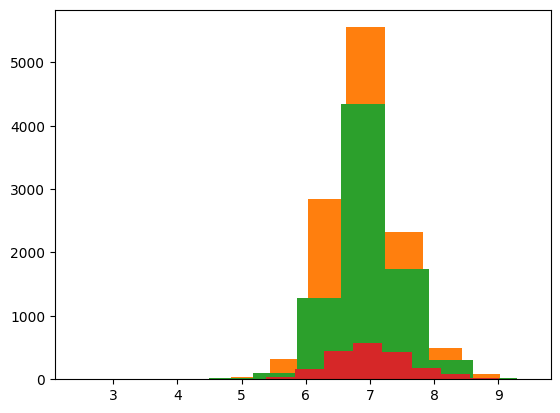

In [149]:
plt.hist(recent.score)
plt.hist(not_recent.score)
plt.hist(old.score)
plt.hist(very_old.score)
plt.show()

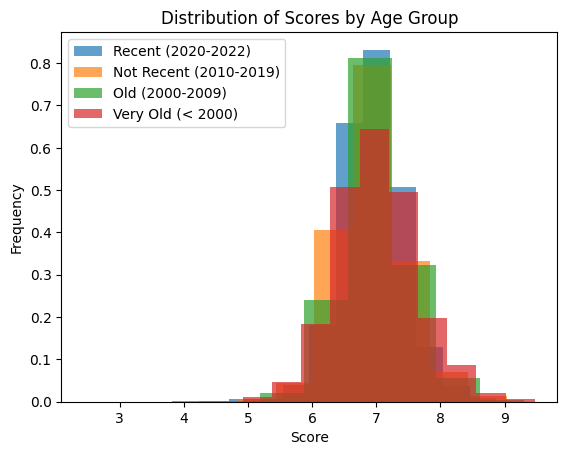

In [150]:
plt.hist(recent.score,label='Recent (2020-2022)', alpha=0.7, density=True)
plt.hist(not_recent.score,label='Not Recent (2010-2019)', alpha=0.7, density=True)
plt.hist(old.score,label='Old (2000-2009)', alpha=0.7, density=True)
plt.hist(very_old.score,label='Very Old (< 2000)', alpha=0.7, density=True)
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.title('Distribution of Scores by Age Group')
plt.legend()
plt.show()

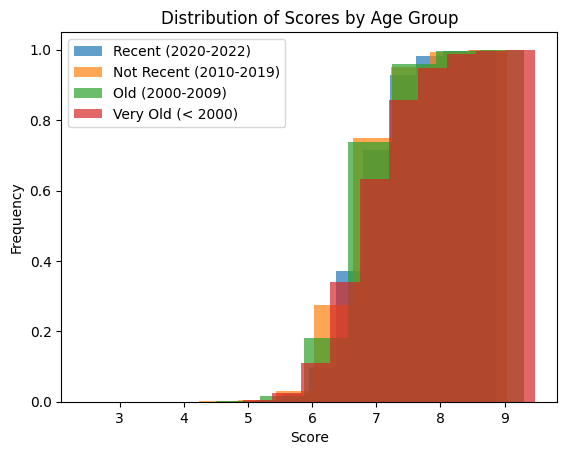

In [151]:
plt.hist(recent.score,label='Recent (2020-2022)', alpha=0.7, density=True, cumulative=True )
plt.hist(not_recent.score,label='Not Recent (2010-2019)', alpha=0.7, density=True, cumulative=True)
plt.hist(old.score,label='Old (2000-2009)', alpha=0.7, density=True, cumulative=True)
plt.hist(very_old.score,label='Very Old (< 2000)', alpha=0.7, density=True, cumulative=True)
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.title('Distribution of Scores by Age Group')
plt.legend()
plt.show()

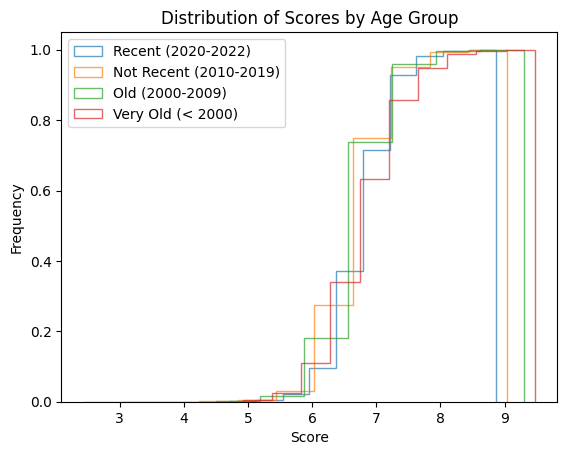

In [152]:
plt.hist(recent.score,label='Recent (2020-2022)', alpha=0.7, density=True, cumulative=True, histtype='step') 
plt.hist(not_recent.score,label='Not Recent (2010-2019)', alpha=0.7, density=True, cumulative=True, histtype='step')
plt.hist(old.score,label='Old (2000-2009)', alpha=0.7, density=True, cumulative=True, histtype='step')
plt.hist(very_old.score,label='Very Old (< 2000)', alpha=0.7, density=True, cumulative=True, histtype='step')
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.title('Distribution of Scores by Age Group')
plt.legend()
plt.show()

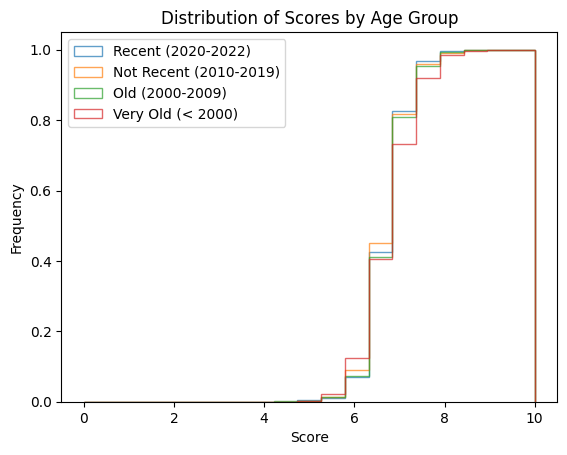

In [154]:
plt.hist(recent.score,label='Recent (2020-2022)', alpha=0.7, density=True, cumulative=True, histtype='step', bins=np.linspace(0, 10, 20)) 
plt.hist(not_recent.score,label='Not Recent (2010-2019)', alpha=0.7, density=True, cumulative=True, histtype='step', bins=np.linspace(0, 10, 20))
plt.hist(old.score,label='Old (2000-2009)', alpha=0.7, density=True, cumulative=True, histtype='step', bins=np.linspace(0, 10, 20))
plt.hist(very_old.score,label='Very Old (< 2000)', alpha=0.7, density=True, cumulative=True, histtype='step', bins=np.linspace(0, 10, 20))
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.title('Distribution of Scores by Age Group')
plt.legend()
plt.show()

In [155]:
len(recent), len(not_recent), len(old), len(very_old)

(6706, 33129, 16961, 5573)